# Hybrid Forecast + Change-Point Evaluation

This notebook runs `src/evaluate.py`, loads metrics from `results/evaluation/`, and saves all generated plots to `results/plots/`.

In [1]:
from __future__ import annotations

import json
import os
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print('Project root:', ROOT)
print('Python:', sys.executable)
# If needed: pip install ruptures
# !{sys.executable} -m pip install ruptures


Project root: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository
Python: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/.venv/bin/python


In [2]:
MODELS = ['lstm', 'deepar', 'chronos2']
HORIZON = 48
CONTEXT_LENGTH = 48
SAMPLING_MODE = 'random'
RANDOM_WINDOWS_PER_SERIES = 50
RANDOM_SEED = 42
RANDOM_WITH_REPLACEMENT = True
PAIRED_RANDOM_WINDOWS = True
FORECASTER_QUANTILES = '0.5,0.95'  # use '0.5,0.95' for retrained quantile LSTM
# Chronos2 now uses direct quantile outputs from model tensor indices.
DATASET_PATH = ROOT / 'data' / 'data_1to7.csv'
EVAL_DIR = ROOT / 'results' / 'evaluation'
PLOTS_DIR = ROOT / 'results' / 'plots'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

cmd = [
    sys.executable,
    str(ROOT / 'src' / 'evaluate.py'),
    '--models', ','.join(MODELS),
    '--data-path', str(DATASET_PATH),
    '--horizon', str(HORIZON),
    '--context-length', str(CONTEXT_LENGTH),
    '--sampling-mode', SAMPLING_MODE,
    '--random-windows-per-series', str(RANDOM_WINDOWS_PER_SERIES),
    '--random-seed', str(RANDOM_SEED),
    '--forecaster-quantiles', FORECASTER_QUANTILES,
    '--cp-penalty', '10',
    '--cp-min-size', '8',
    '--output-dir', str(EVAL_DIR),
]

if RANDOM_WITH_REPLACEMENT:
    cmd.append('--random-with-replacement')
else:
    cmd.append('--random-without-replacement')

if PAIRED_RANDOM_WINDOWS:
    cmd.append('--paired-random-windows')
else:
    cmd.append('--independent-random-windows')

print('Running:', ' '.join(cmd))
subprocess.run(cmd, cwd=ROOT, check=True)
print('Evaluation completed on full dataset with probabilistic trajectories:', DATASET_PATH)
print('Evaluation metrics folder:', EVAL_DIR)
print('Plots folder:', PLOTS_DIR)


Running: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/.venv/bin/python /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/src/evaluate.py --models lstm,deepar,chronos2 --data-path /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/data/data_1to7.csv --horizon 48 --context-length 48 --sampling-mode random --random-windows-per-series 50 --random-seed 42 --forecaster-quantiles 0.5,0.95 --cp-penalty 10 --cp-min-size 8 --output-dir /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/evaluation --random-with-replacement --paired-random-windows


/Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/.venv/lib/python3.13/site-packages/ruptures/costs/costnormal.py:28: UserWarning: New behaviour in v1.1.5: a small bias is added to the covariance matrix to cope with truly constant segments (see PR#198).
  warnings.warn(


[lstm] MAE_CP=6.3474 Coverage=0.9770 Sharpness=4.2007


/Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/.venv/lib/python3.13/site-packages/ruptures/costs/costnormal.py:28: UserWarning: New behaviour in v1.1.5: a small bias is added to the covariance matrix to cope with truly constant segments (see PR#198).
  warnings.warn(


[deepar] MAE_CP=5.8670 Coverage=0.9474 Sharpness=2.2294


/Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/.venv/lib/python3.13/site-packages/ruptures/costs/costnormal.py:28: UserWarning: New behaviour in v1.1.5: a small bias is added to the covariance matrix to cope with truly constant segments (see PR#198).
  warnings.warn(


[chronos2] MAE_CP=6.1498 Coverage=0.9564 Sharpness=3.5815
Saved summary: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/evaluation/evaluation_summary.json
Evaluation completed on full dataset with probabilistic trajectories: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/data/data_1to7.csv
Evaluation metrics folder: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/evaluation
Plots folder: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/plots


,model,MAE_CP,coverage_rate,sharpness,tolerance_hit_rate,num_windows_total,sampling_mode,random_windows_per_series,paired_random_windows,bound_definition
0,chronos2,6.149767,0.956362,3.581518,0.467209,4300,random,50,True,safe_ceiling=max(y_pred_95[0:tau_pred])
1,deepar,5.866977,0.947409,2.229428,0.502093,4300,random,50,True,safe_ceiling=max(y_pred_95[0:tau_pred])
2,lstm,6.347442,0.976987,4.200704,0.494651,4300,random,50,True,safe_ceiling=max(y_pred_95[0:tau_pred])


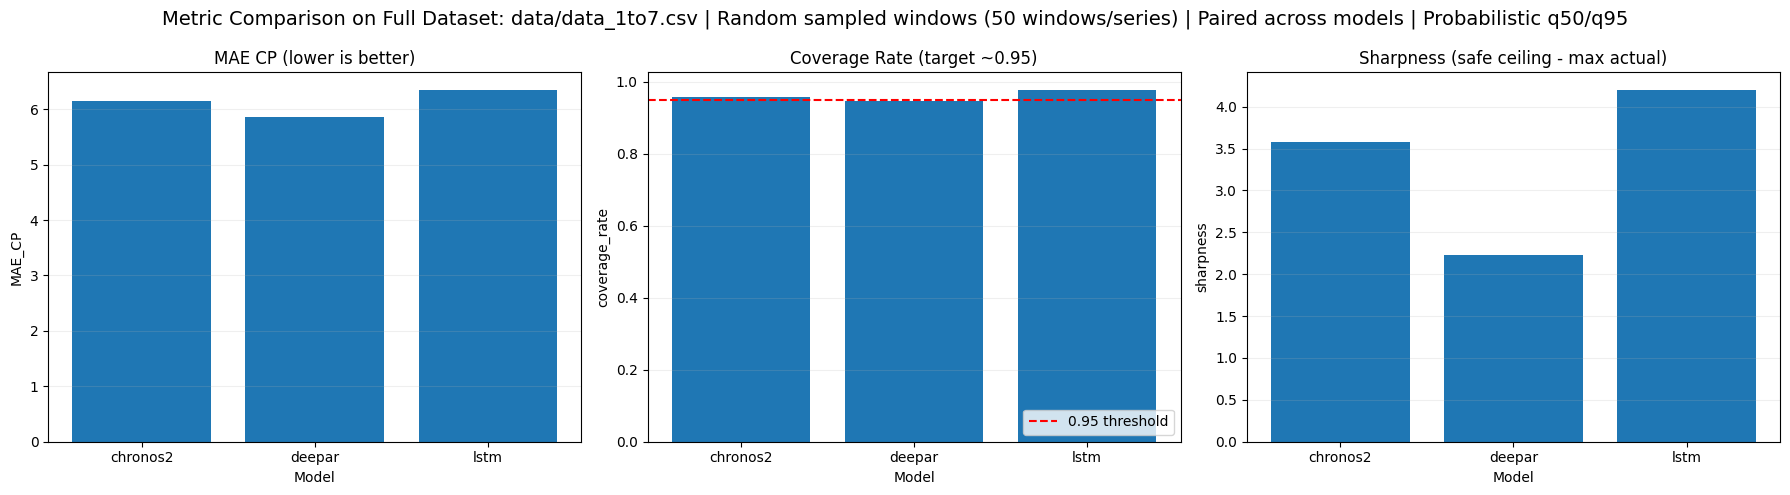

Saved plot: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/plots/benchmark_lstm_deepar_chronos2_data_1to7.png


In [3]:
FULL_DATASET_LABEL = 'data/data_1to7.csv'

metrics_rows = []
for model in MODELS:
    path = EVAL_DIR / f'{model}_metrics.json'
    if not path.exists():
        print(f'Skipping missing metrics: {path}')
        continue
    payload = json.loads(path.read_text())
    metrics_rows.append({
        'model': payload['model'],
        'MAE_CP': payload['MAE_CP'],
        'coverage_rate': payload['coverage_rate'],
        'sharpness': payload['sharpness'],
        'tolerance_hit_rate': payload['tolerance_hit_rate'],
        'num_windows_total': payload['num_windows_total'],
        'sampling_mode': payload.get('sampling_mode'),
        'random_windows_per_series': payload.get('random_windows_per_series'),
        'paired_random_windows': payload.get('paired_random_windows'),
        'bound_definition': payload.get('bound_definition'),
    })

metrics_df = pd.DataFrame(metrics_rows).sort_values('model').reset_index(drop=True)
display(metrics_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics_to_plot = ['MAE_CP', 'coverage_rate', 'sharpness']
titles = ['MAE CP (lower is better)', 'Coverage Rate (target ~0.95)', 'Sharpness (safe ceiling - max actual)']

for ax, metric, title in zip(axes, metrics_to_plot, titles):
    ax.bar(metrics_df['model'], metrics_df[metric])
    ax.set_title(title)
    ax.set_xlabel('Model')
    ax.set_ylabel(metric)
    ax.grid(axis='y', alpha=0.2)
    if metric == 'coverage_rate':
        ax.axhline(0.95, color='red', linestyle='--', linewidth=1.5, label='0.95 threshold')
        ax.legend(loc='lower right')

sampling_text = 'Random sampled windows'
if not metrics_df.empty and pd.notna(metrics_df['random_windows_per_series'].iloc[0]):
    sampling_text += f" ({int(metrics_df['random_windows_per_series'].iloc[0])} windows/series)"
if not metrics_df.empty and bool(metrics_df['paired_random_windows'].iloc[0]):
    sampling_text += ' | Paired across models'
fig.suptitle(
    f'Metric Comparison on Full Dataset: {FULL_DATASET_LABEL} | {sampling_text} | Probabilistic q50/q95',
    fontsize=14,
)
plt.tight_layout()
benchmark_plot_path = PLOTS_DIR / 'benchmark_lstm_deepar_chronos2_data_1to7.png'
plt.savefig(benchmark_plot_path, dpi=160, bbox_inches='tight')
plt.show()
print('Saved plot:', benchmark_plot_path)


Selected shared series: ['T70722B', 'T70722C', 'T70724A', 'T70731A', 'T70744A', 'T78256B', 'T78259C', 'T78262B', 'T78270C', 'T78279A']
Shared start indices by series: {'T70722B': 513, 'T70722C': 563, 'T70724A': 442, 'T70731A': 190, 'T70744A': 1217, 'T78256B': 1018, 'T78259C': 866, 'T78262B': 533, 'T78270C': 1087, 'T78279A': 568}


/Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/.venv/lib/python3.13/site-packages/ruptures/costs/costnormal.py:28: UserWarning: New behaviour in v1.1.5: a small bias is added to the covariance matrix to cope with truly constant segments (see PR#198).
  warnings.warn(


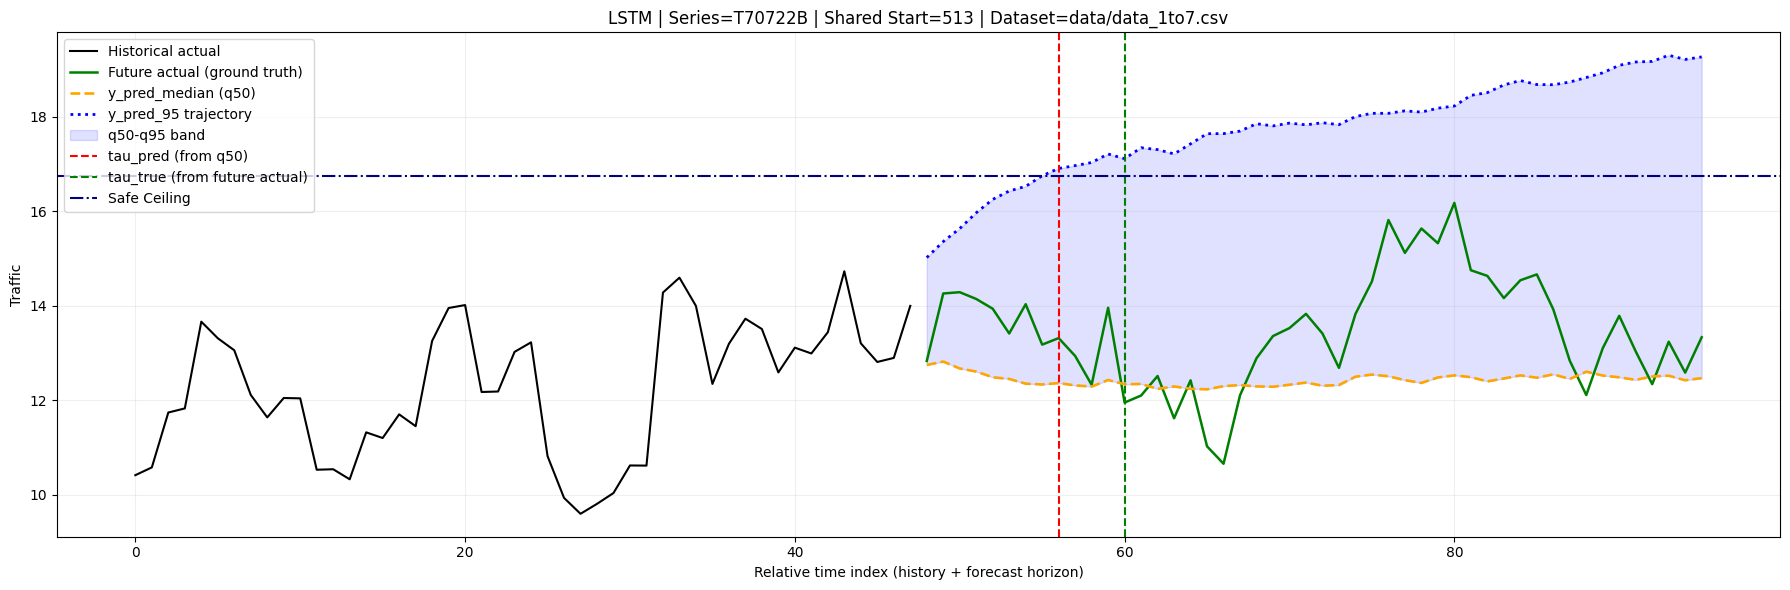

Saved plot: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/plots/plot_prob_T70722B_lstm_start513.png


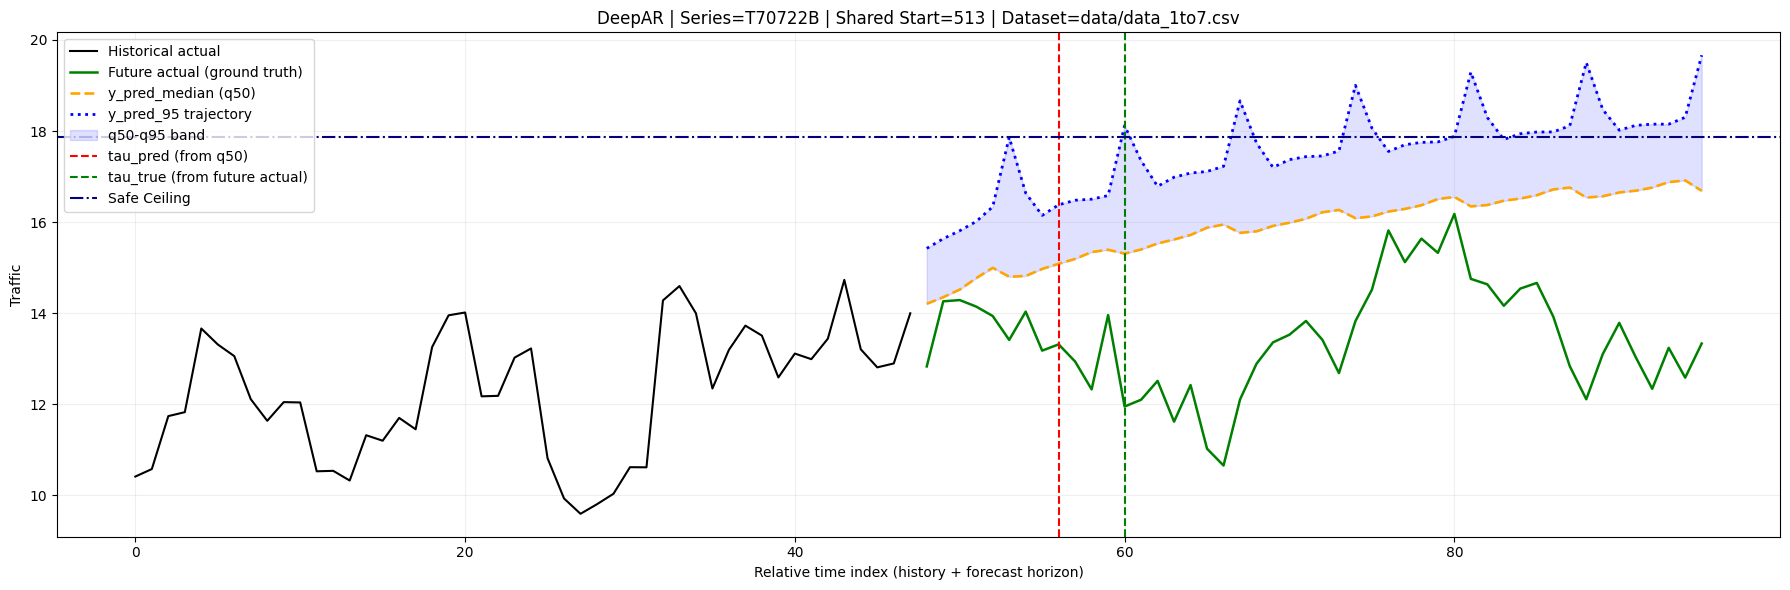

Saved plot: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/plots/plot_prob_T70722B_deepar_start513.png


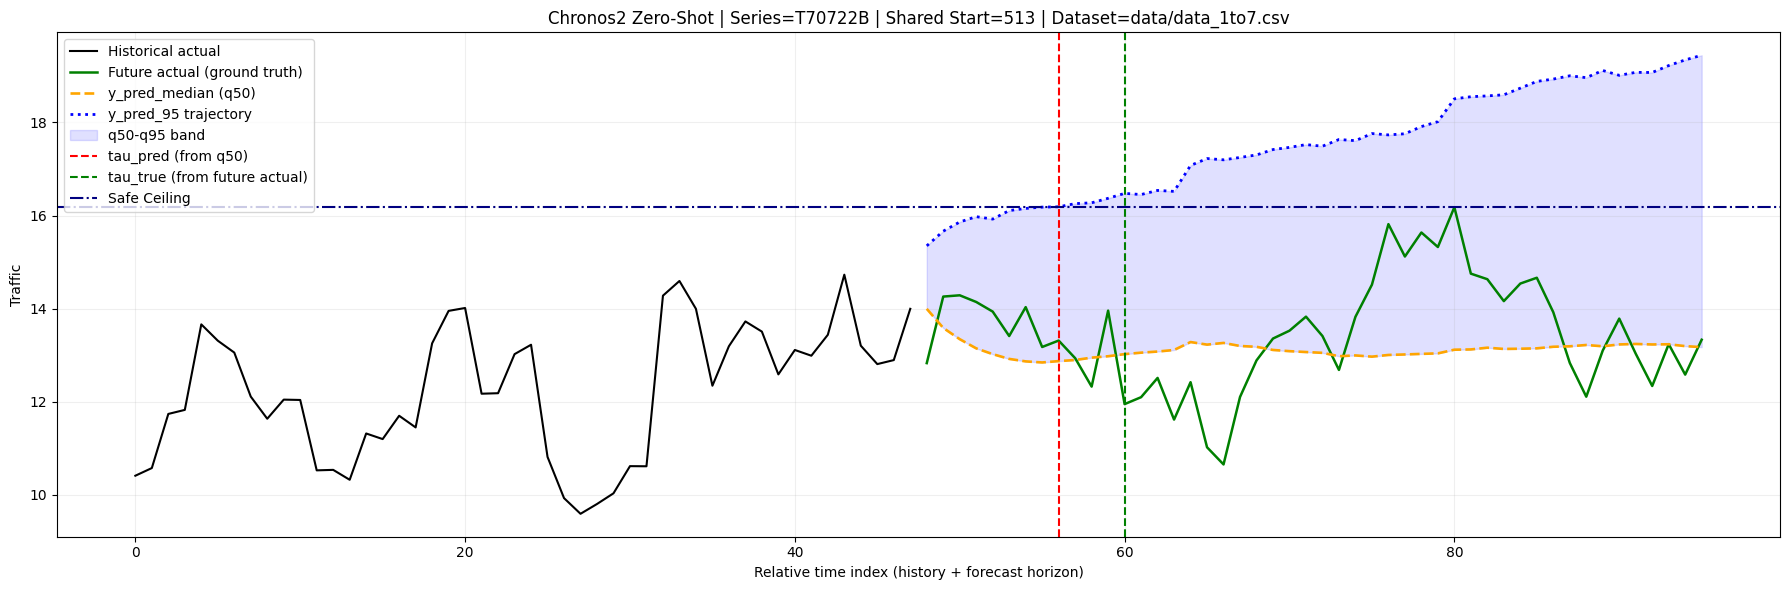

Saved plot: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/plots/plot_prob_T70722B_chronos2_start513.png


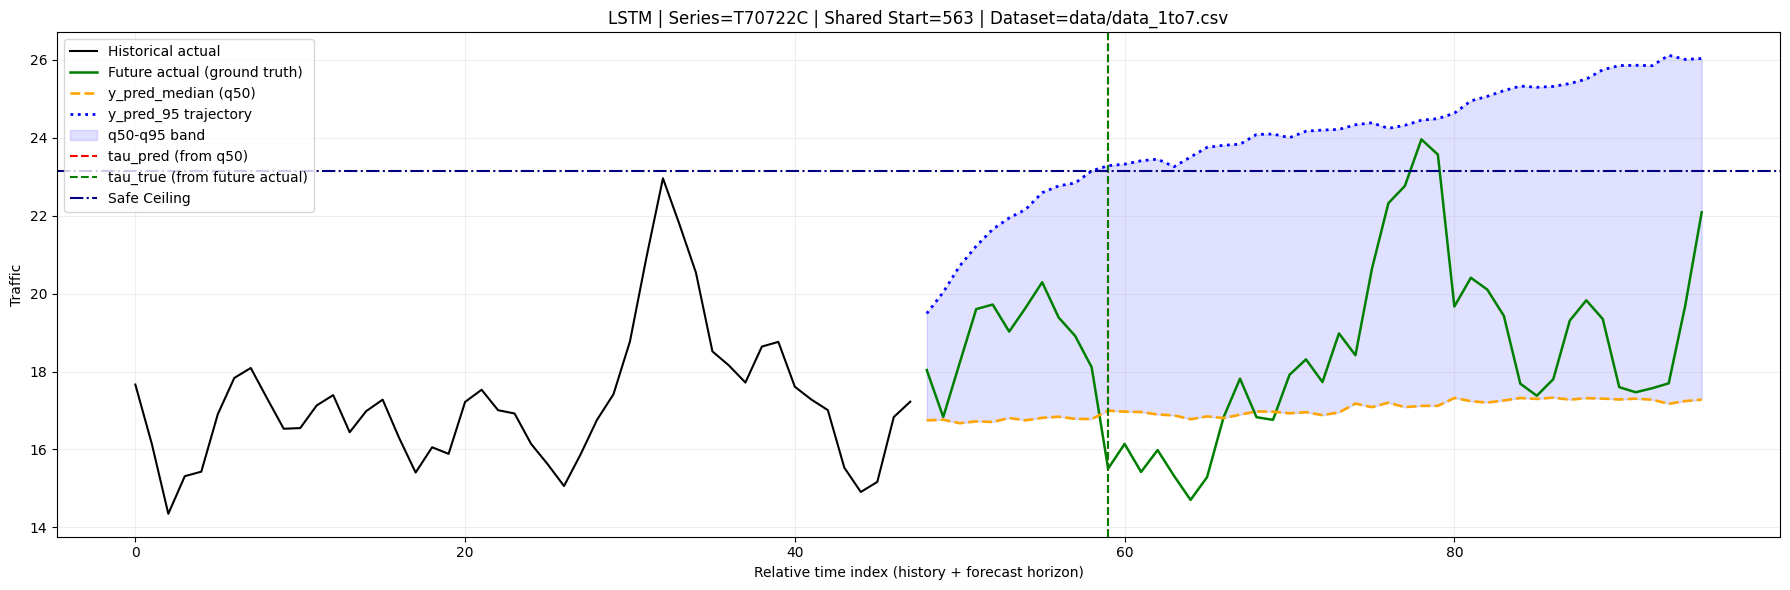

Saved plot: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/plots/plot_prob_T70722C_lstm_start563.png


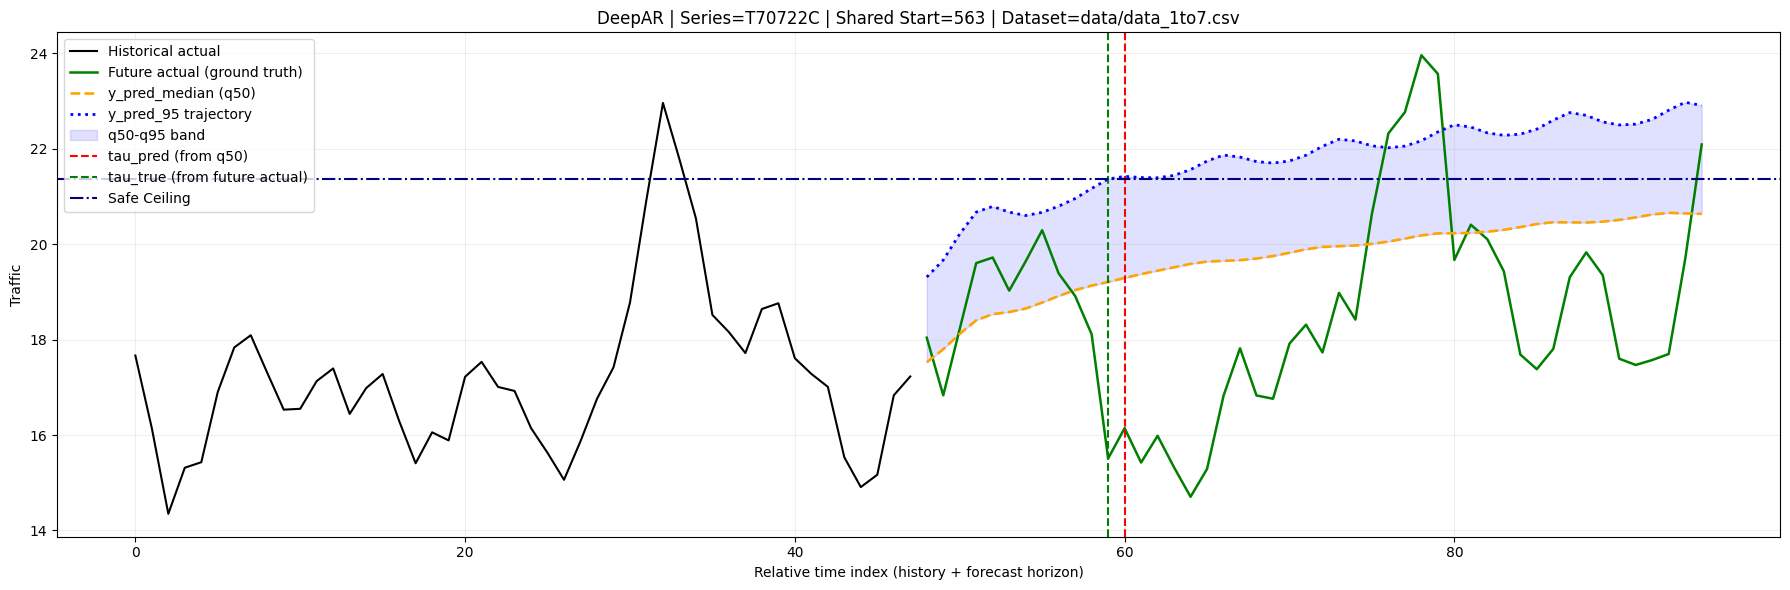

Saved plot: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/plots/plot_prob_T70722C_deepar_start563.png


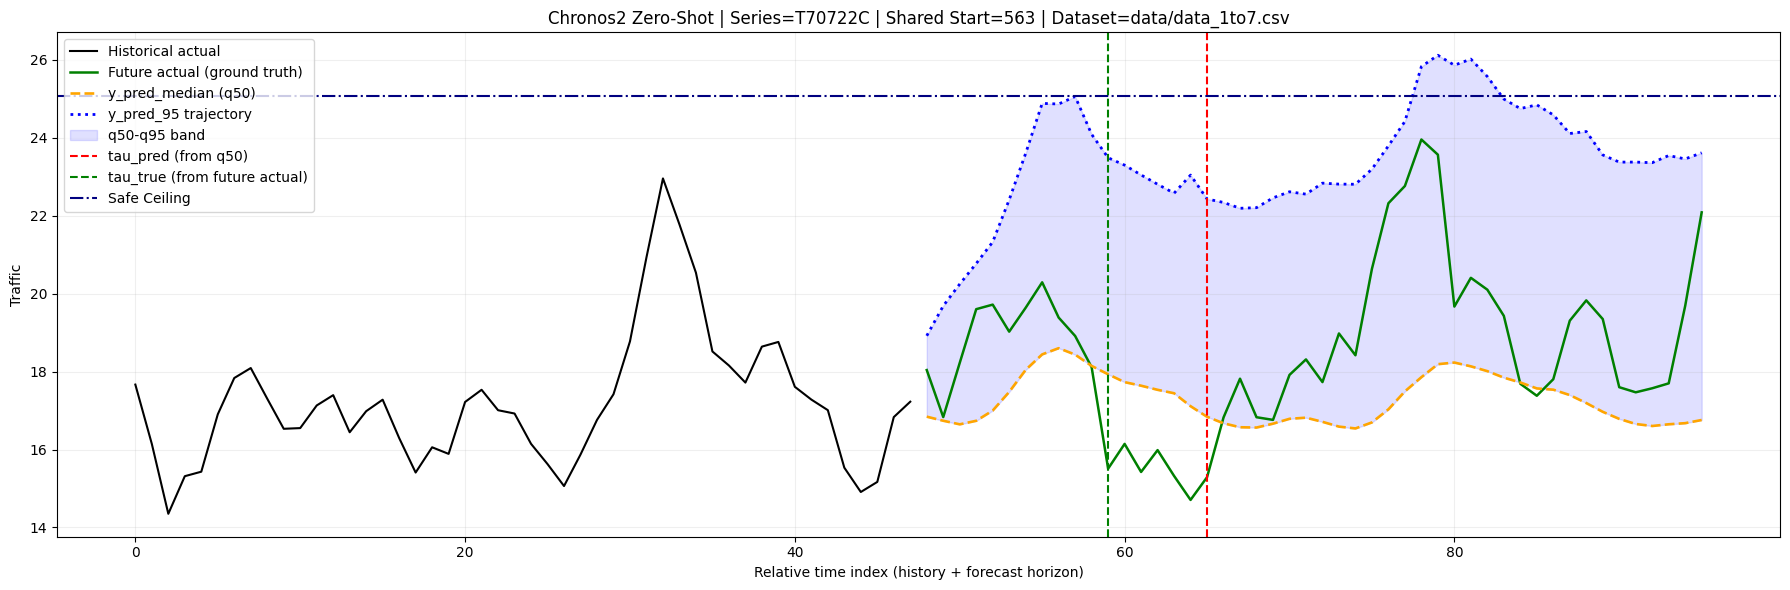

Saved plot: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/plots/plot_prob_T70722C_chronos2_start563.png


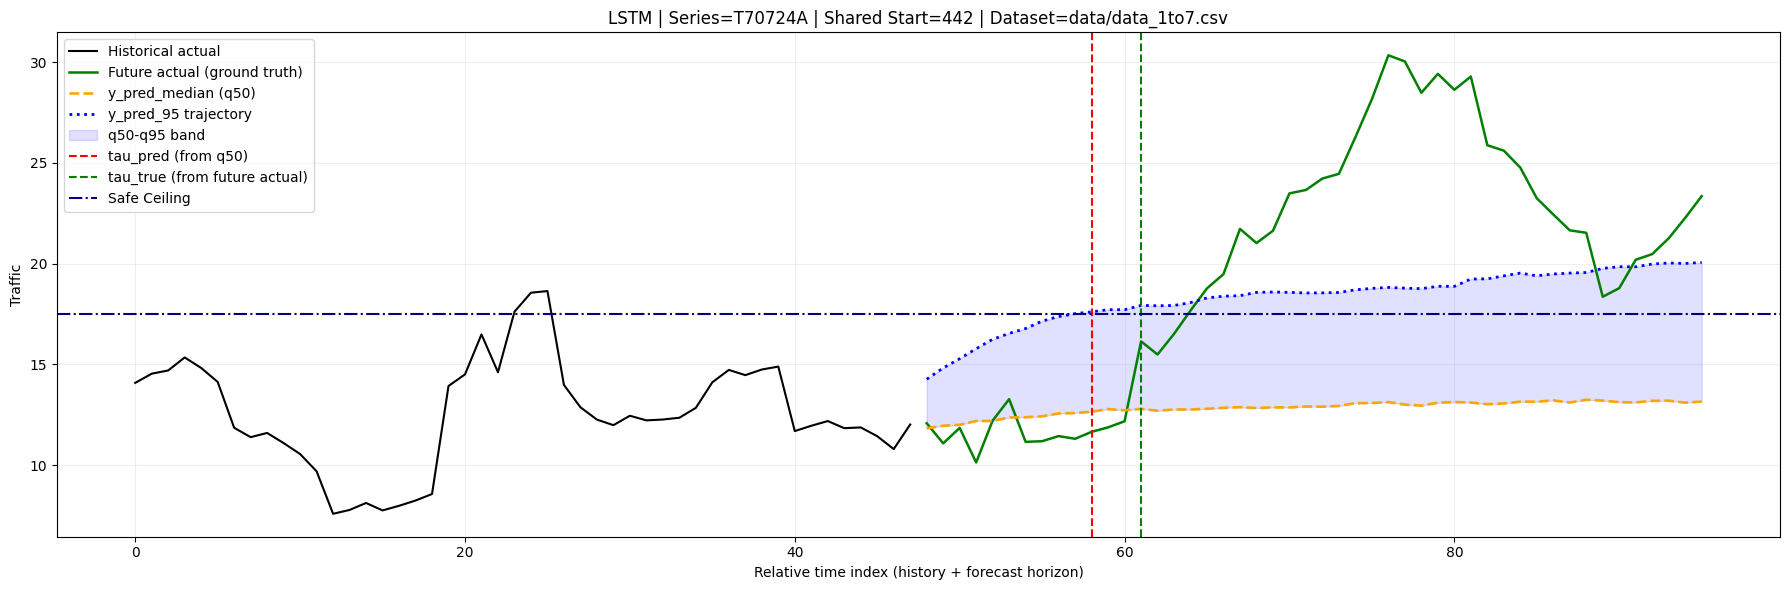

Saved plot: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/plots/plot_prob_T70724A_lstm_start442.png


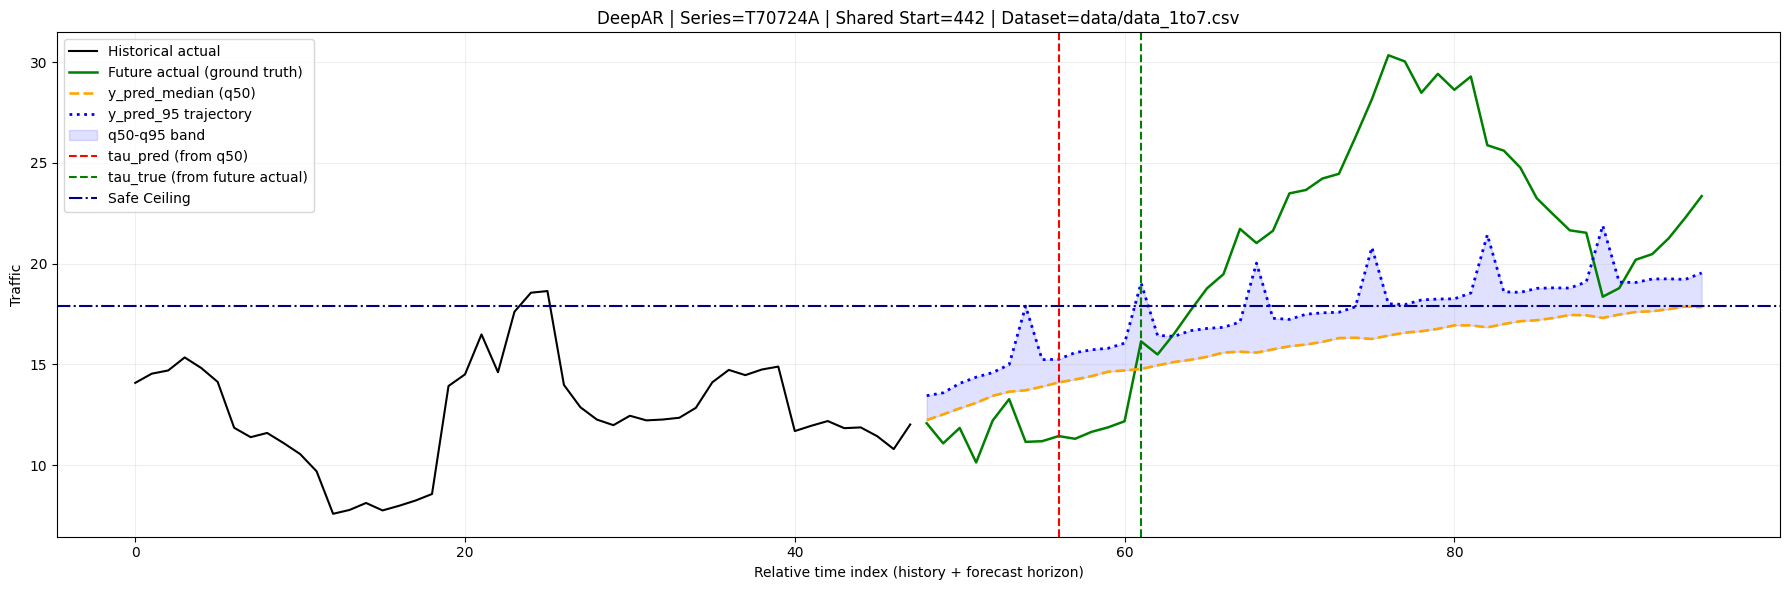

Saved plot: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/plots/plot_prob_T70724A_deepar_start442.png


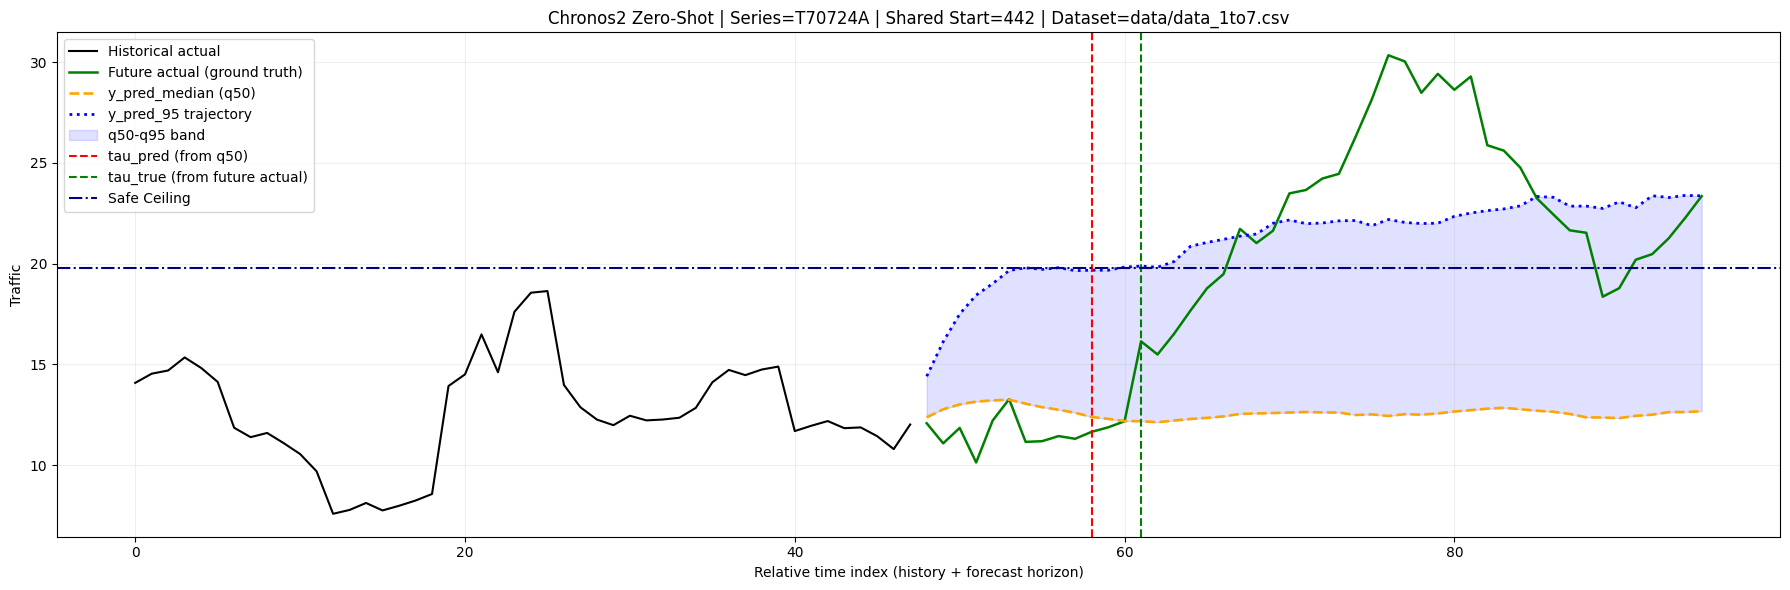

Saved plot: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/plots/plot_prob_T70724A_chronos2_start442.png


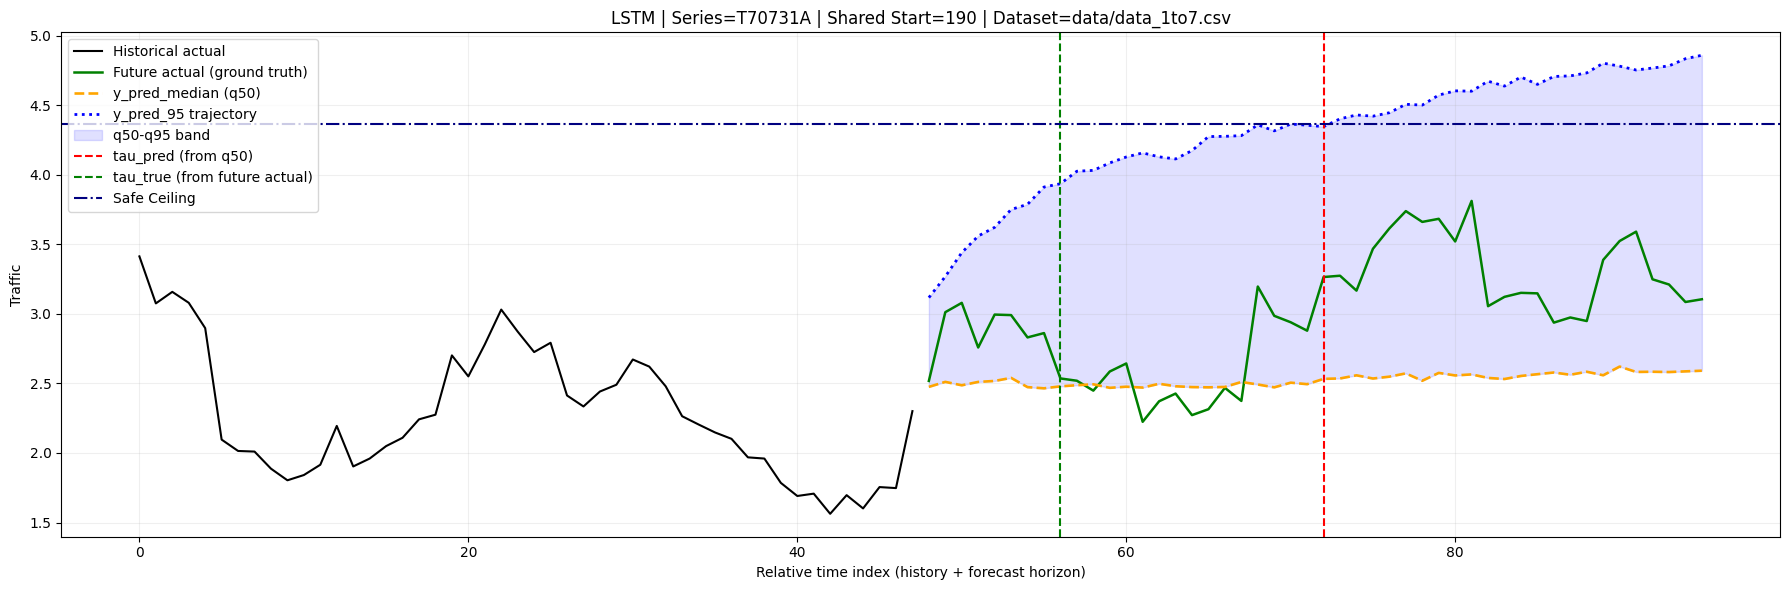

Saved plot: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/plots/plot_prob_T70731A_lstm_start190.png


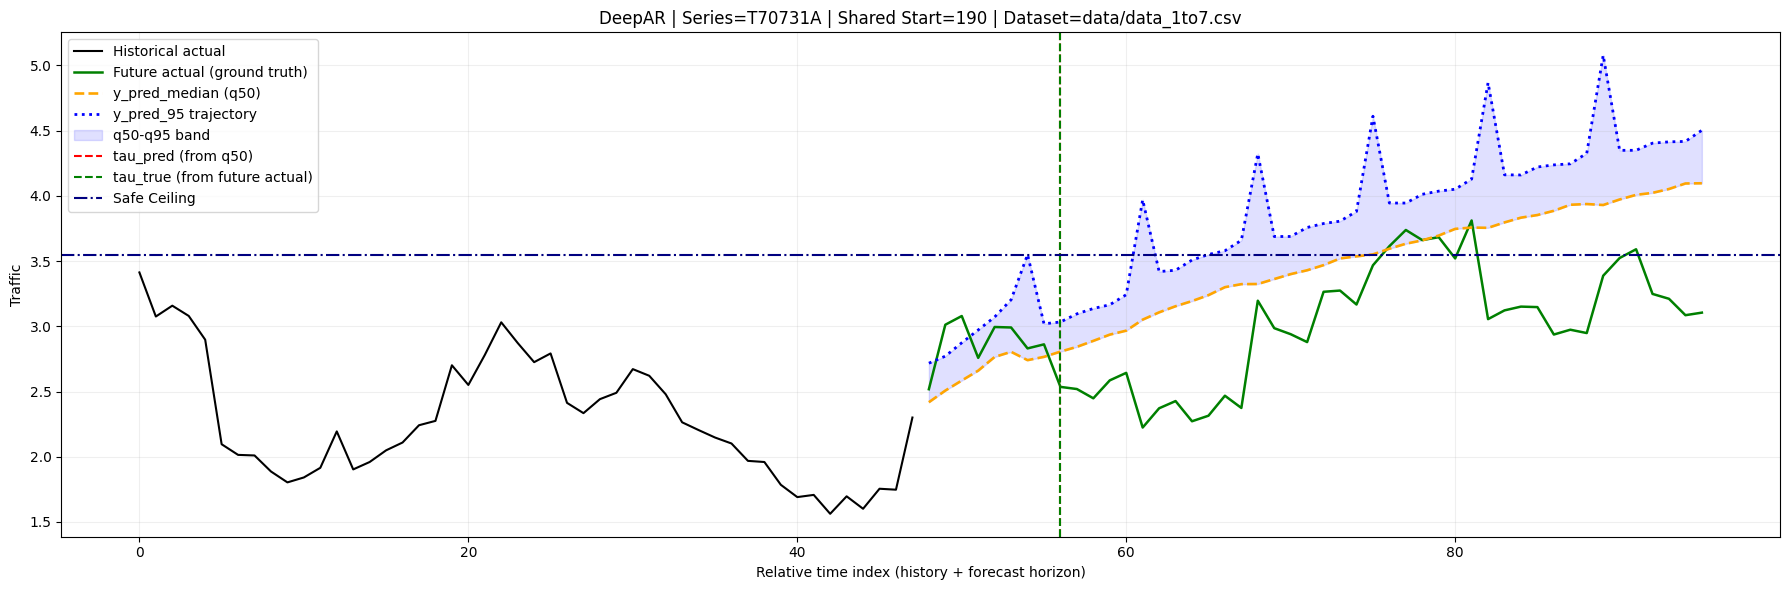

Saved plot: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/plots/plot_prob_T70731A_deepar_start190.png


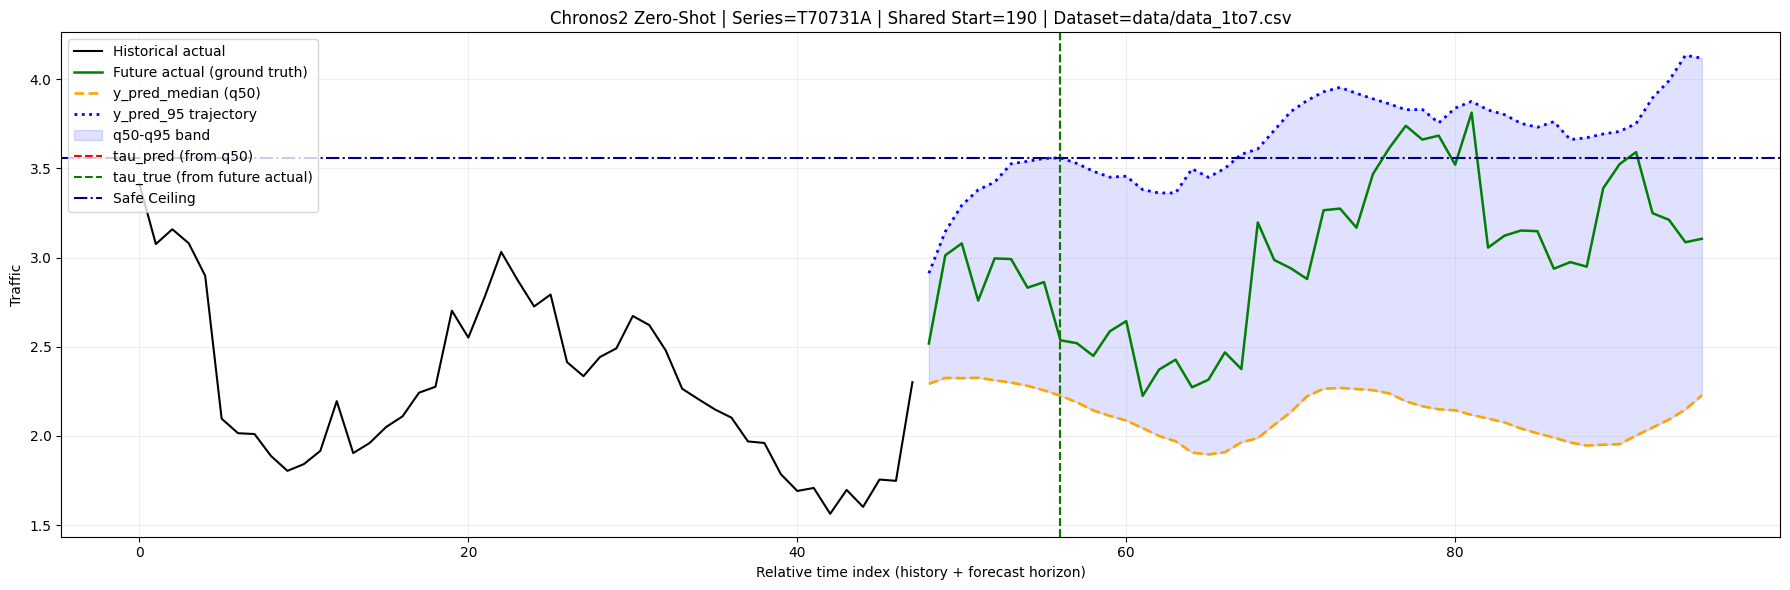

Saved plot: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/plots/plot_prob_T70731A_chronos2_start190.png


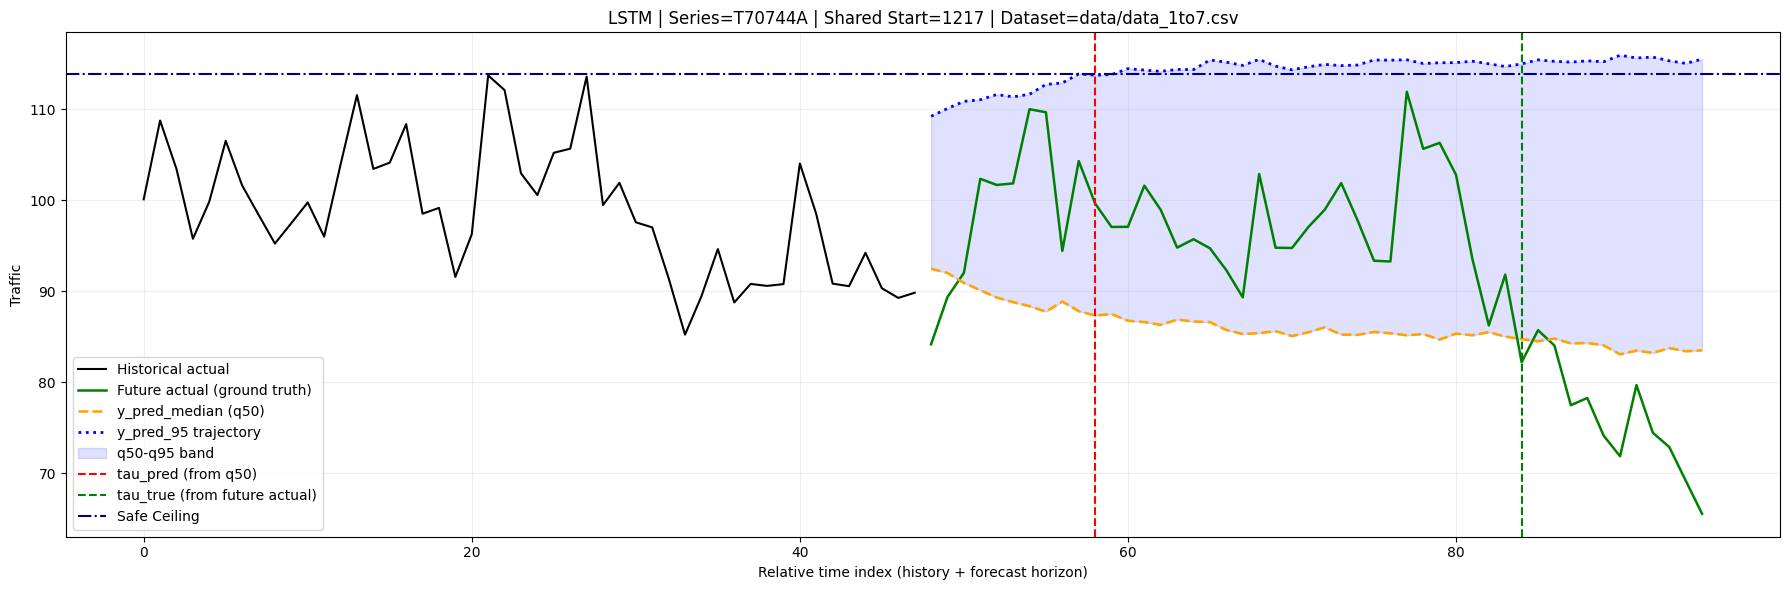

Saved plot: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/plots/plot_prob_T70744A_lstm_start1217.png


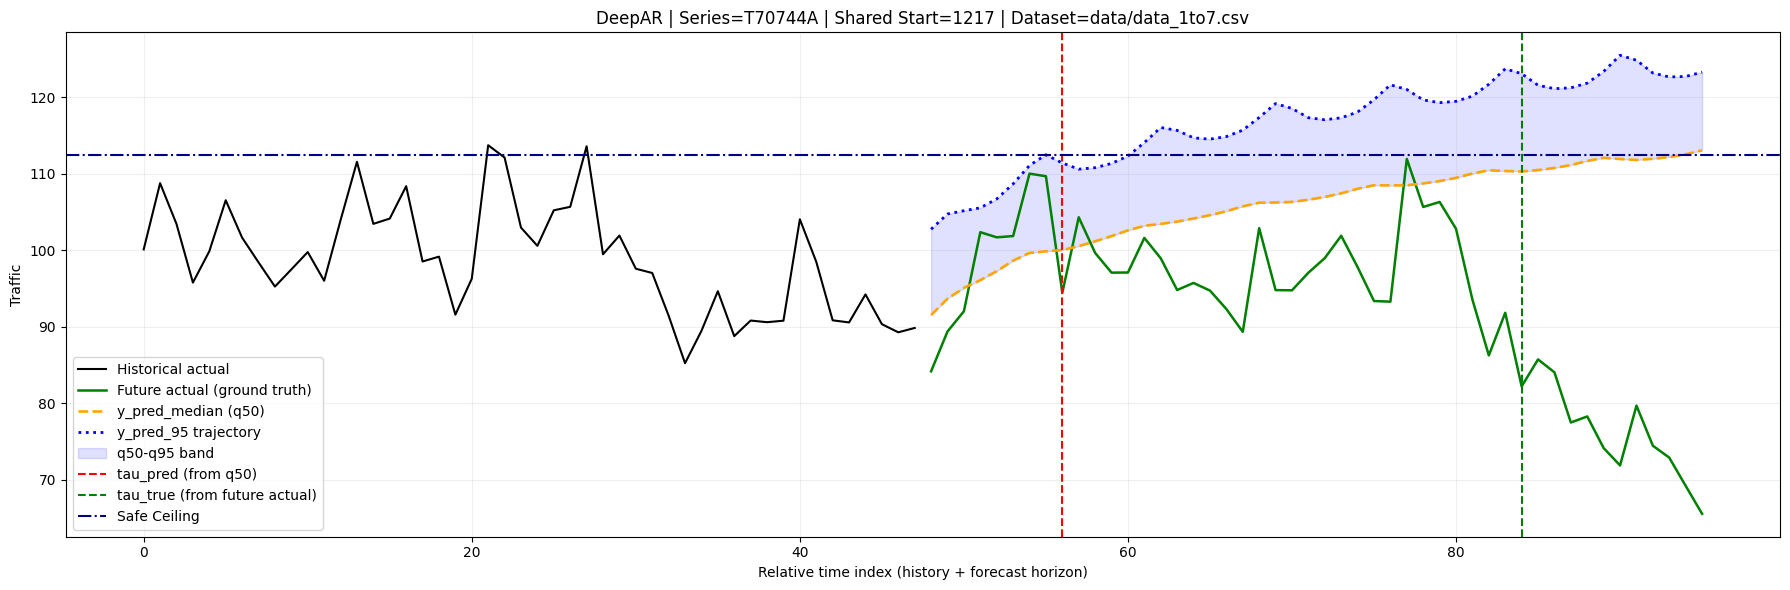

Saved plot: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/plots/plot_prob_T70744A_deepar_start1217.png


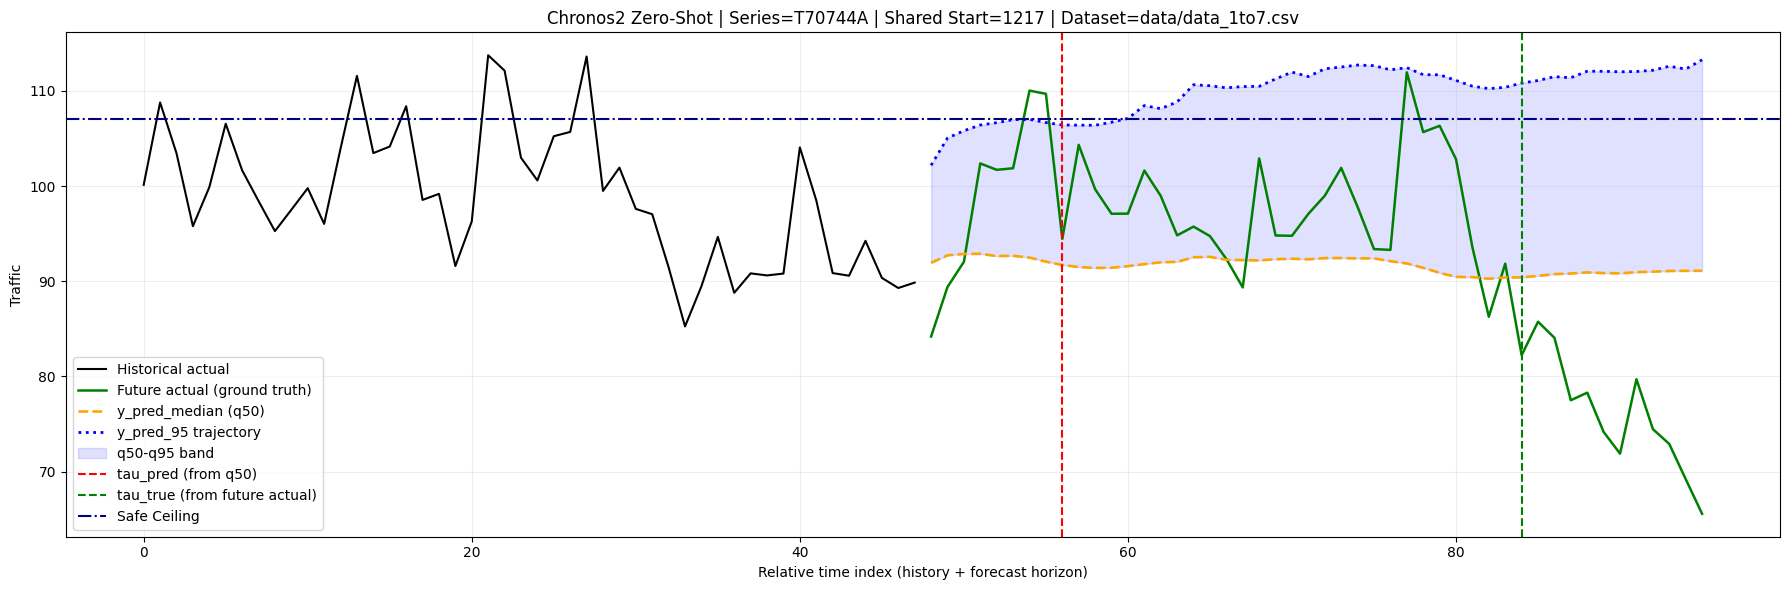

Saved plot: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/plots/plot_prob_T70744A_chronos2_start1217.png


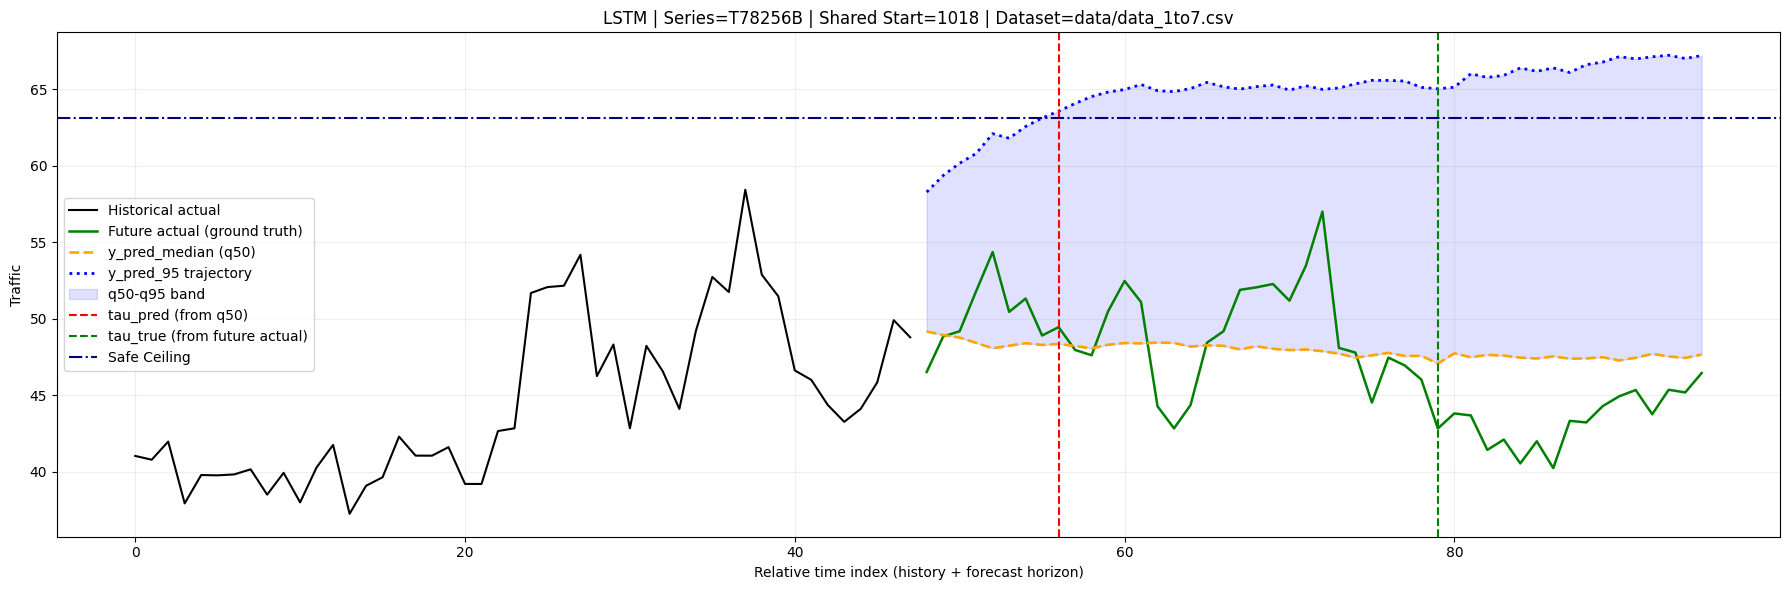

Saved plot: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/plots/plot_prob_T78256B_lstm_start1018.png


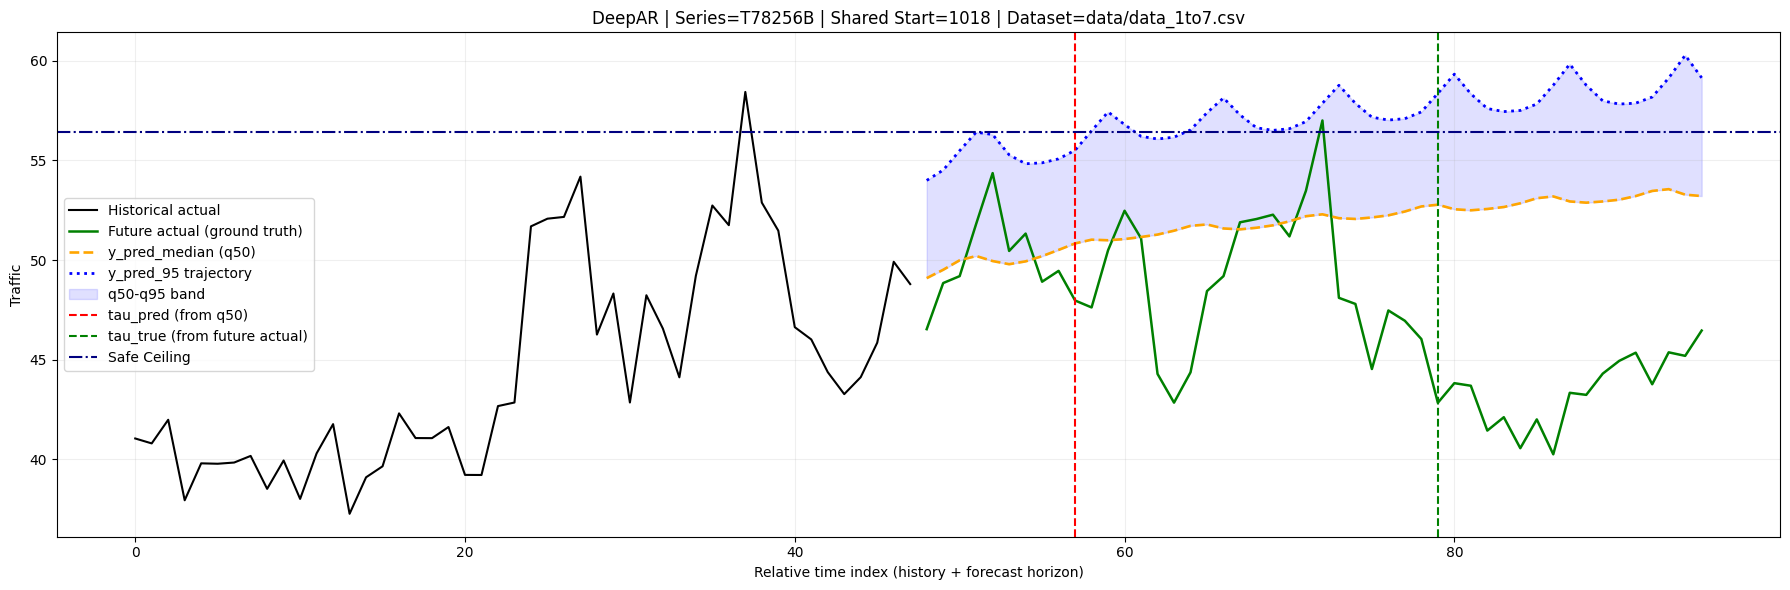

Saved plot: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/plots/plot_prob_T78256B_deepar_start1018.png


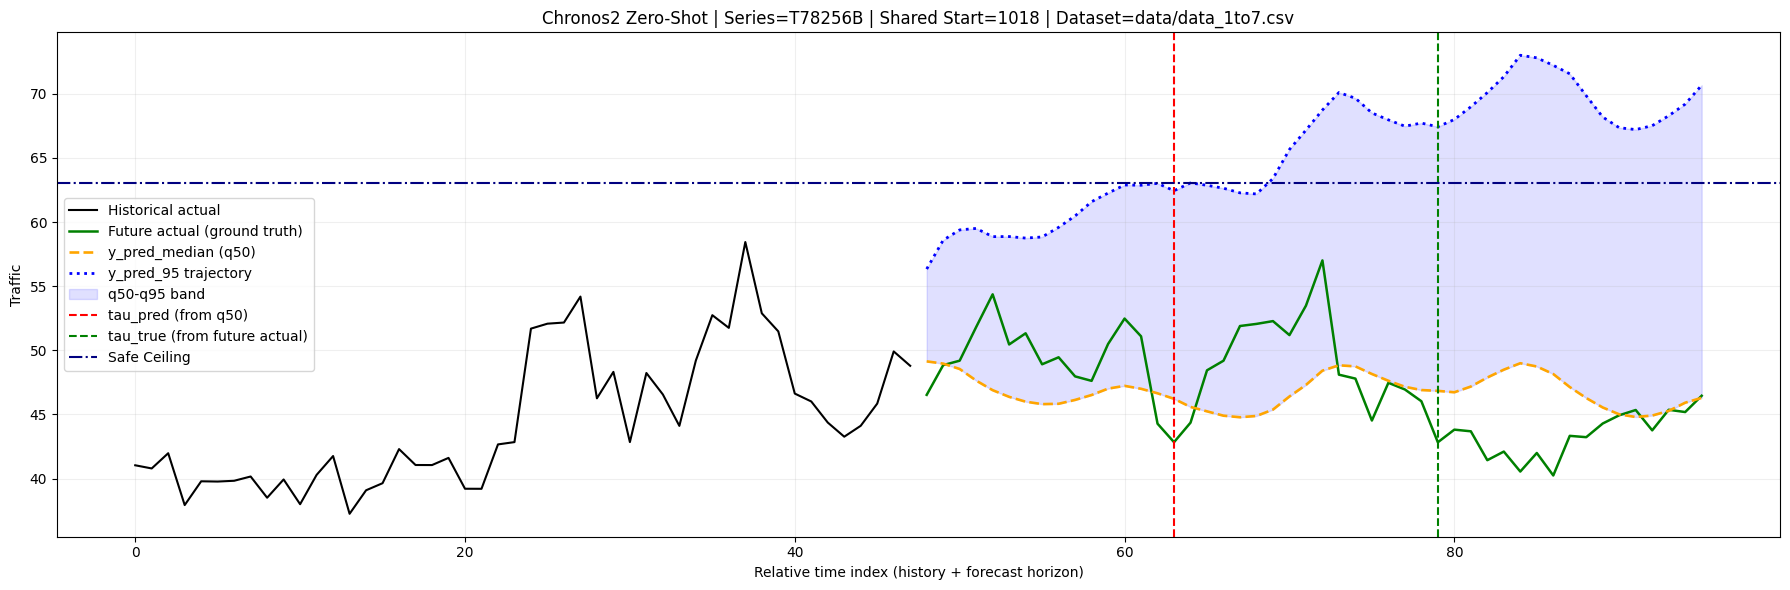

Saved plot: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/plots/plot_prob_T78256B_chronos2_start1018.png


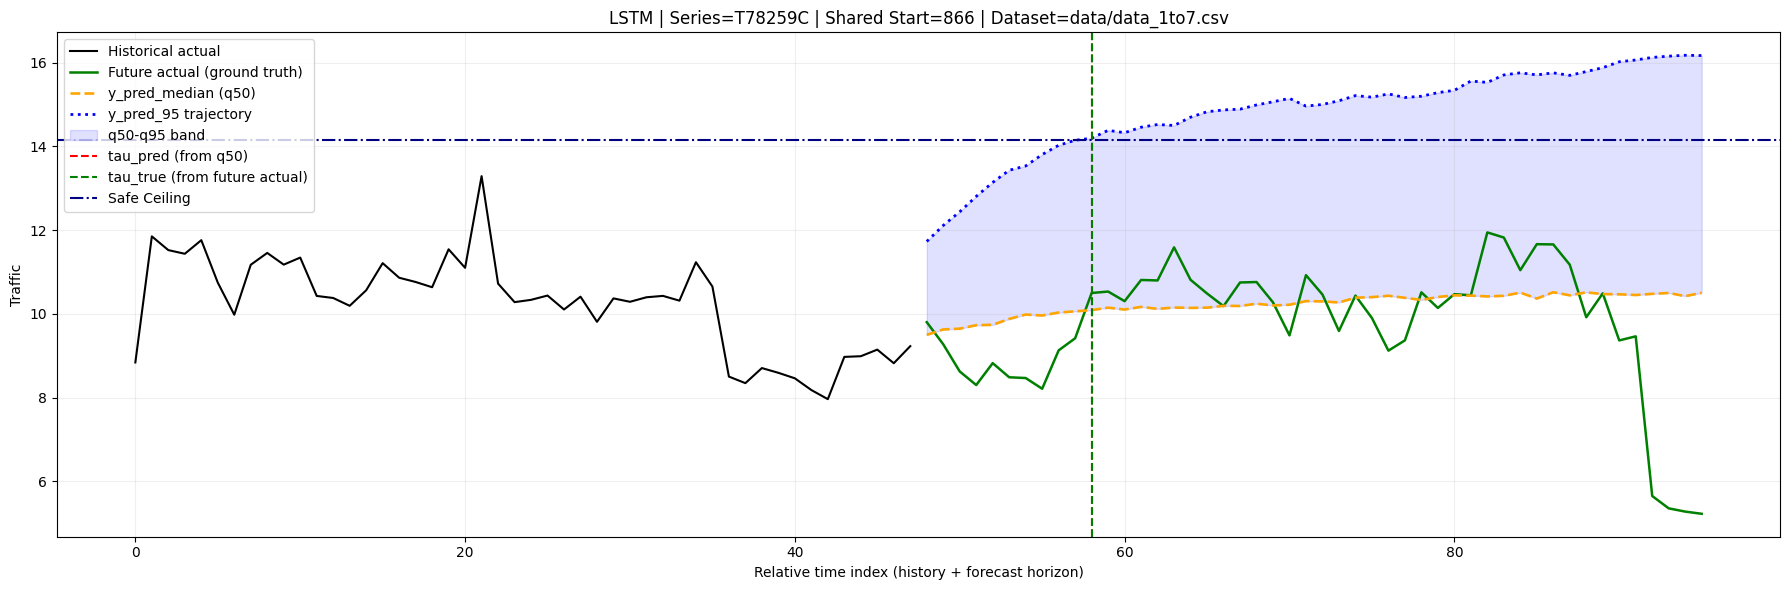

Saved plot: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/plots/plot_prob_T78259C_lstm_start866.png


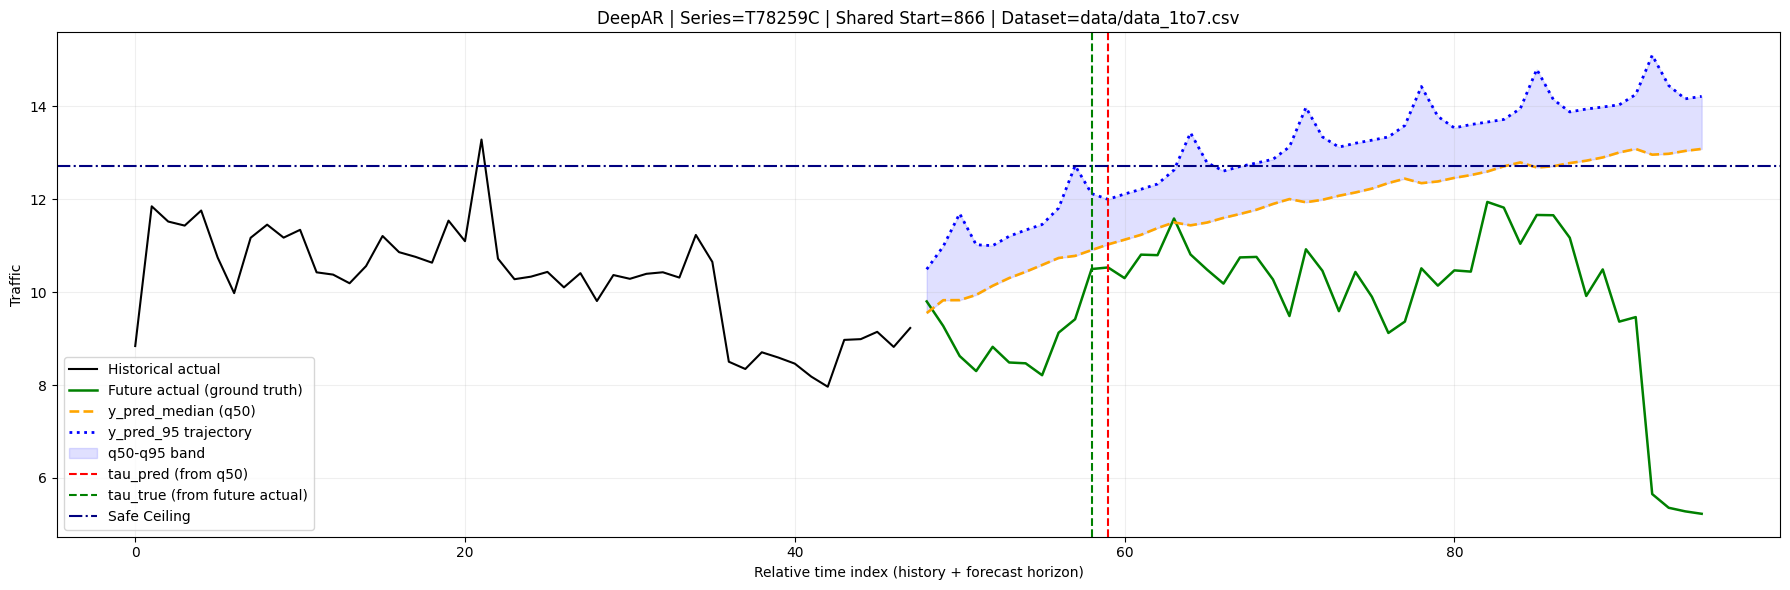

Saved plot: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/plots/plot_prob_T78259C_deepar_start866.png


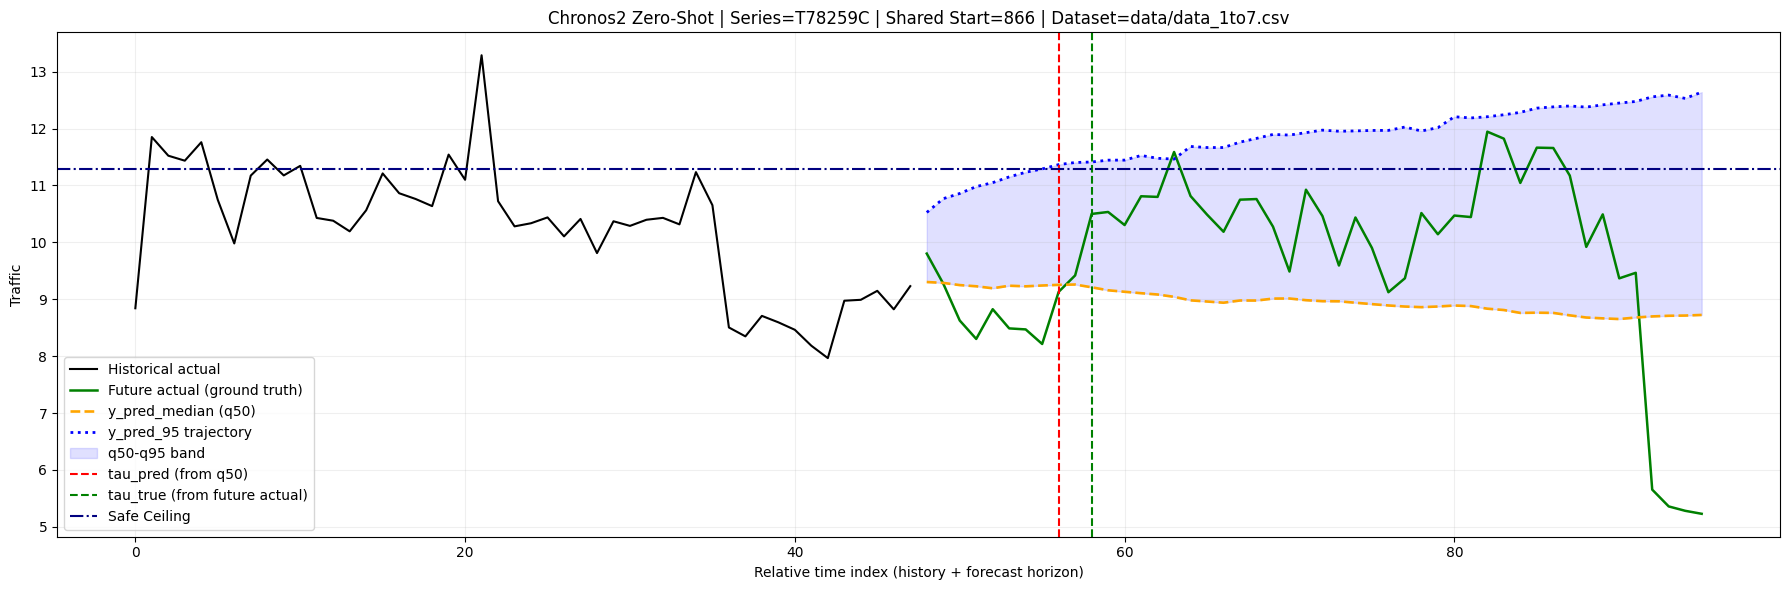

Saved plot: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/plots/plot_prob_T78259C_chronos2_start866.png


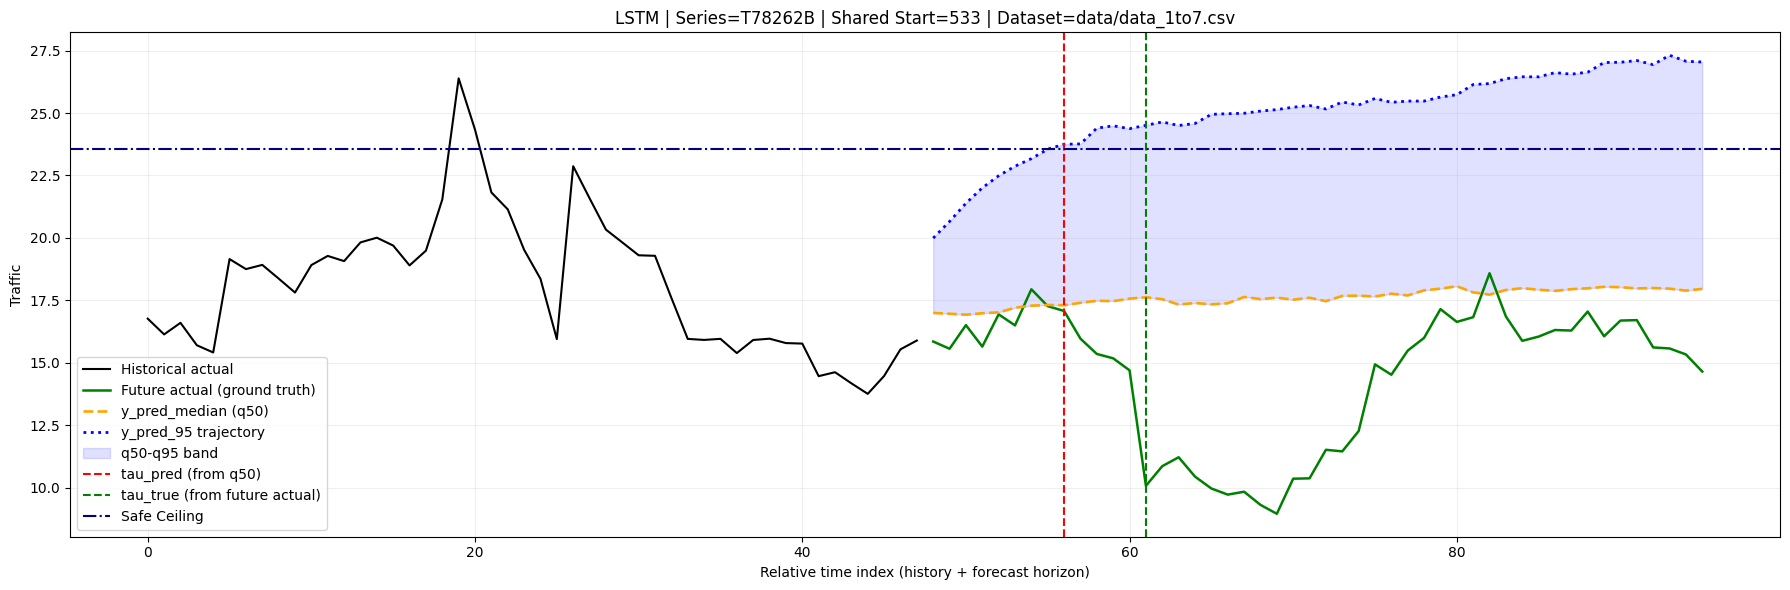

Saved plot: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/plots/plot_prob_T78262B_lstm_start533.png


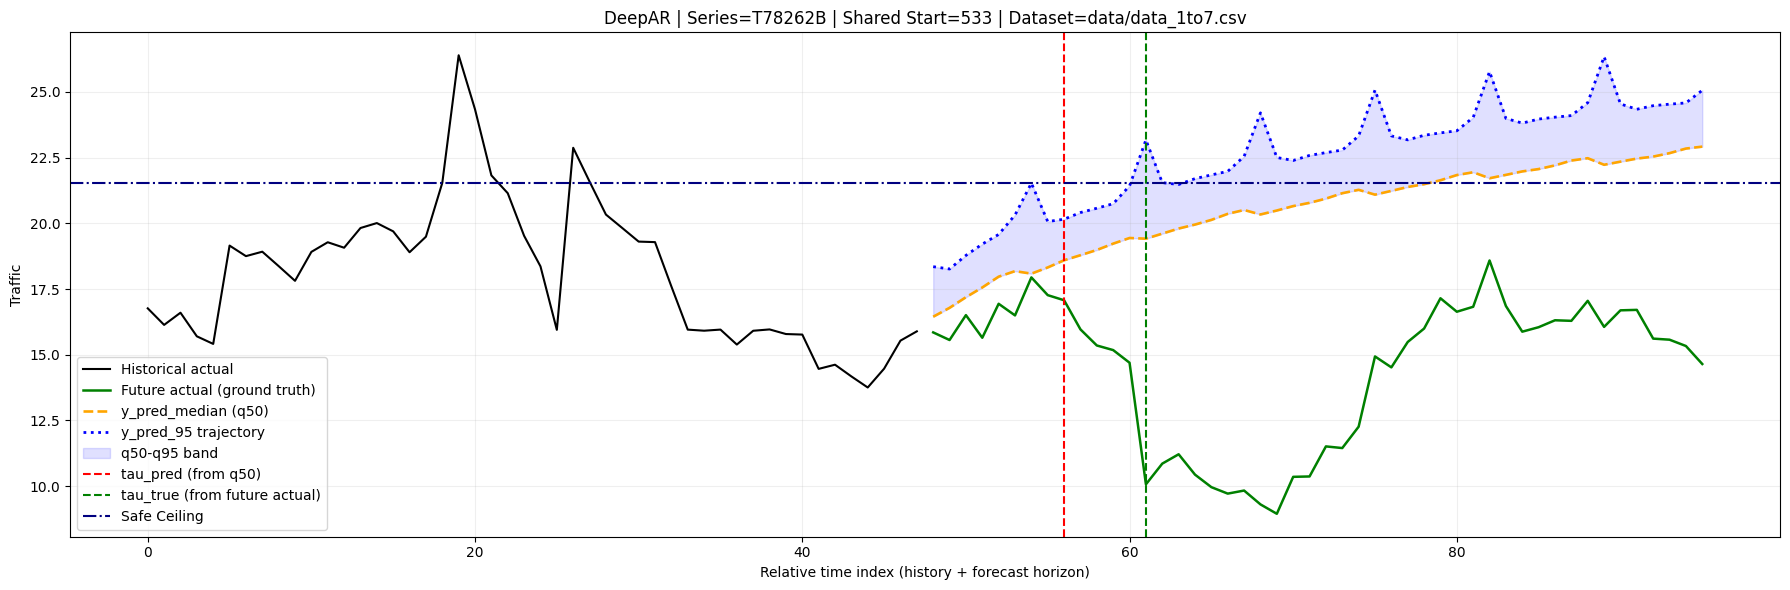

Saved plot: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/plots/plot_prob_T78262B_deepar_start533.png


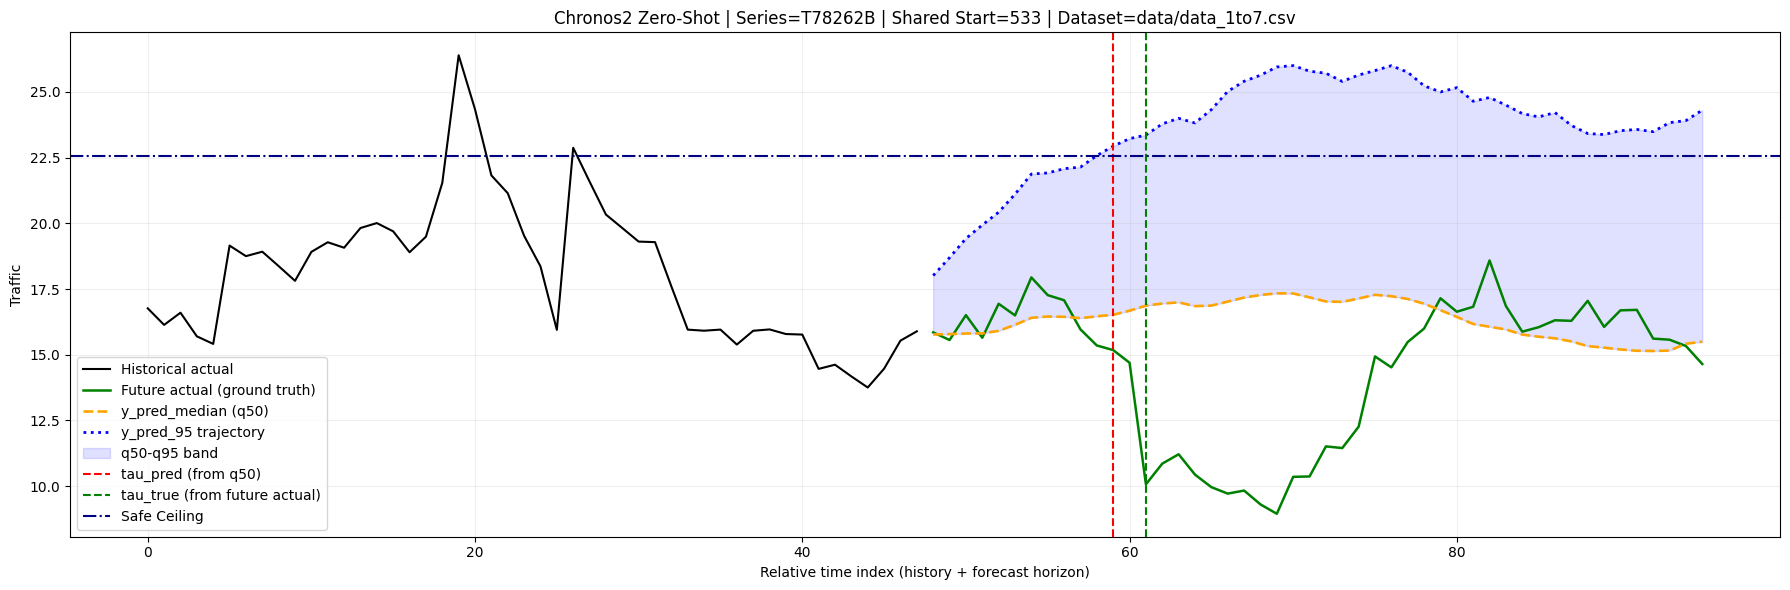

Saved plot: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/plots/plot_prob_T78262B_chronos2_start533.png


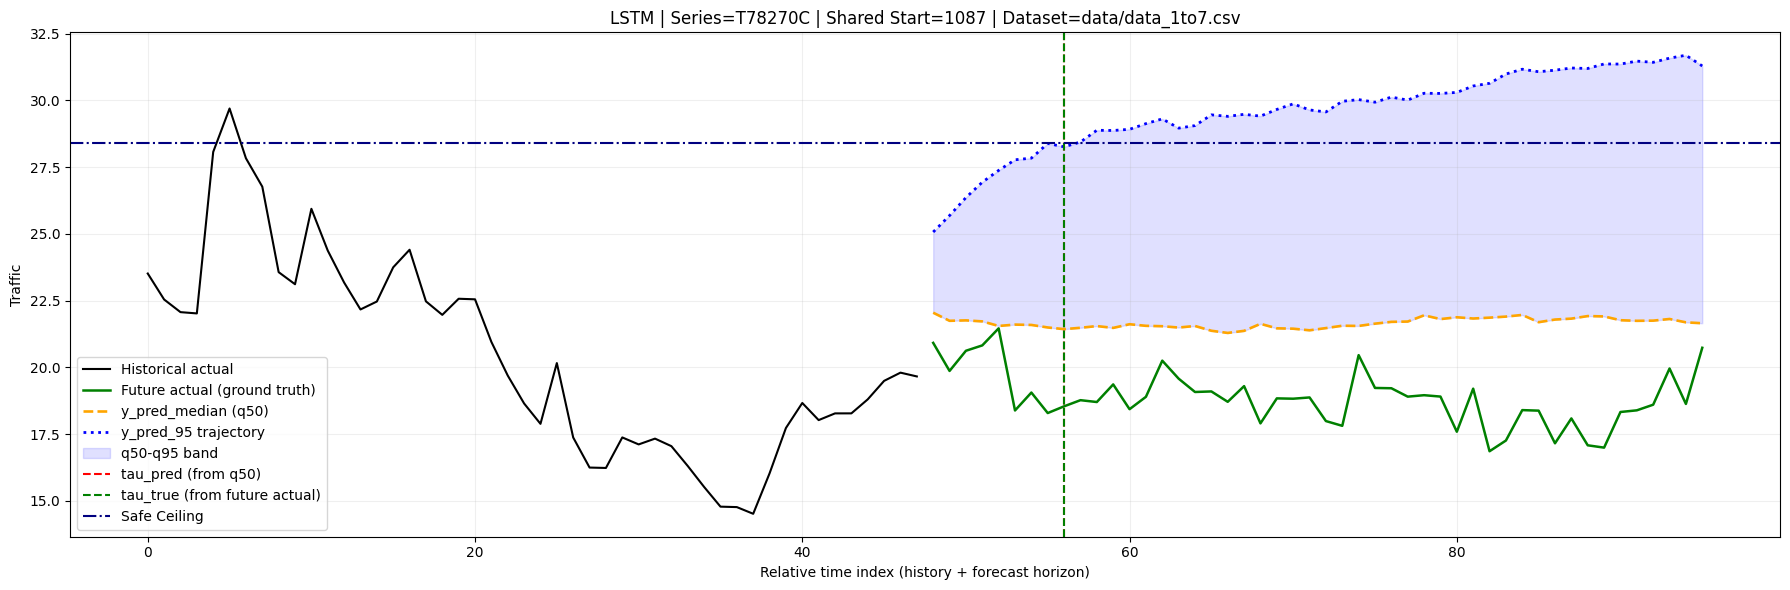

Saved plot: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/plots/plot_prob_T78270C_lstm_start1087.png


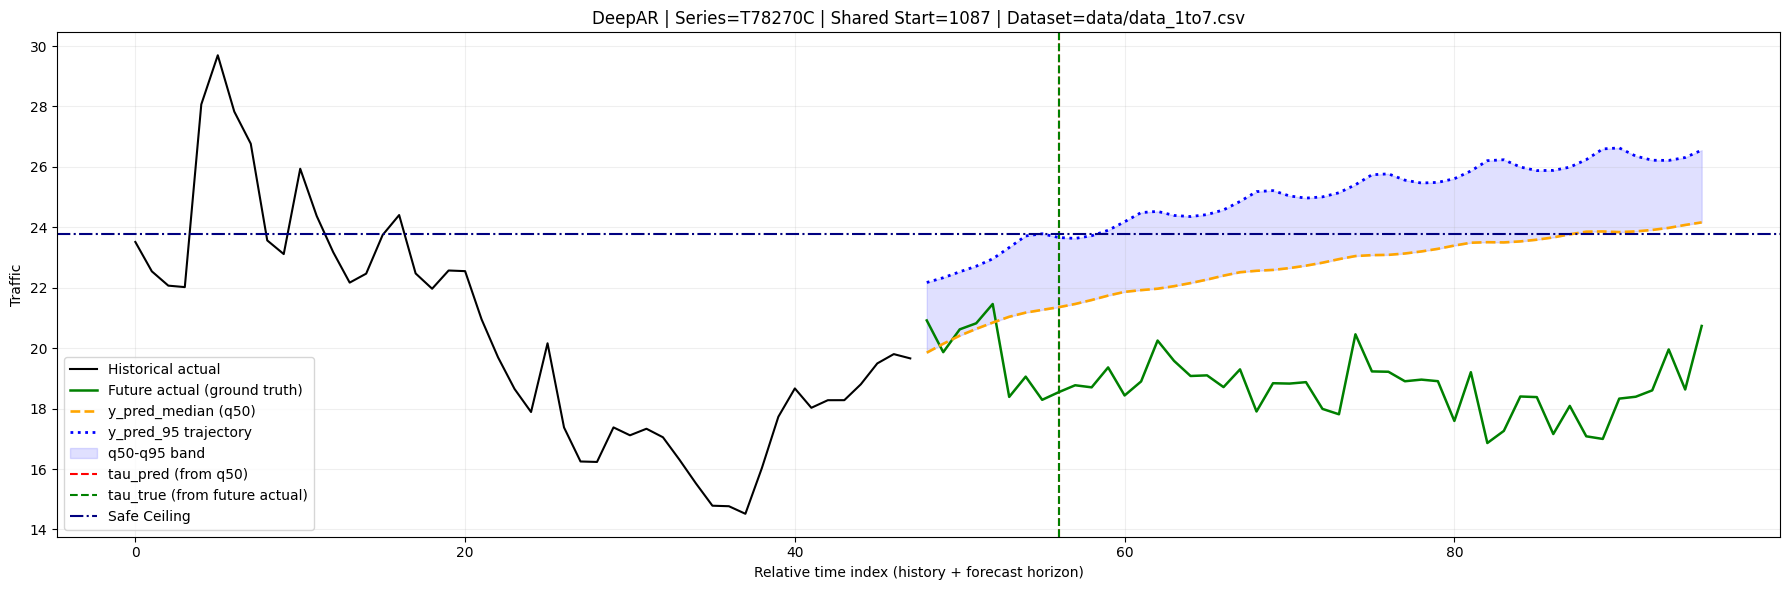

Saved plot: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/plots/plot_prob_T78270C_deepar_start1087.png


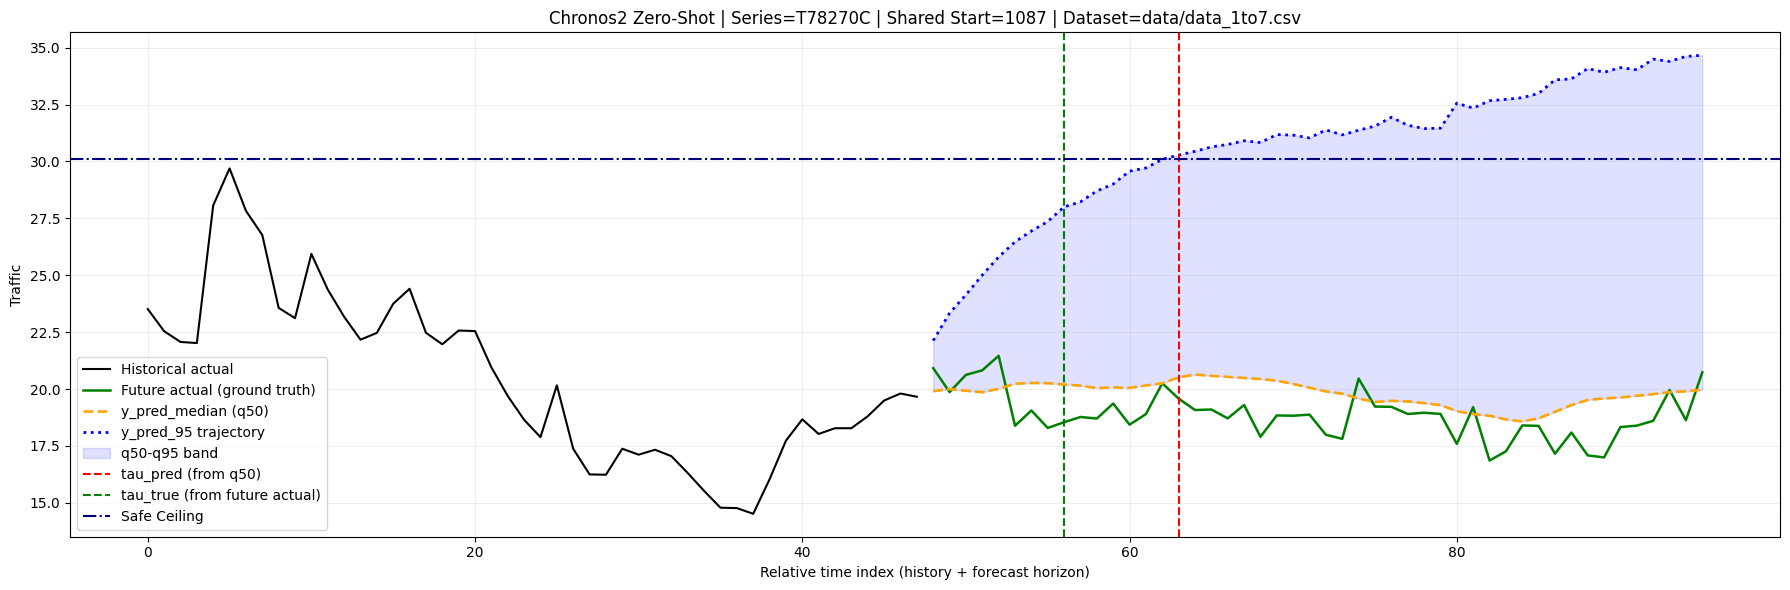

Saved plot: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/plots/plot_prob_T78270C_chronos2_start1087.png


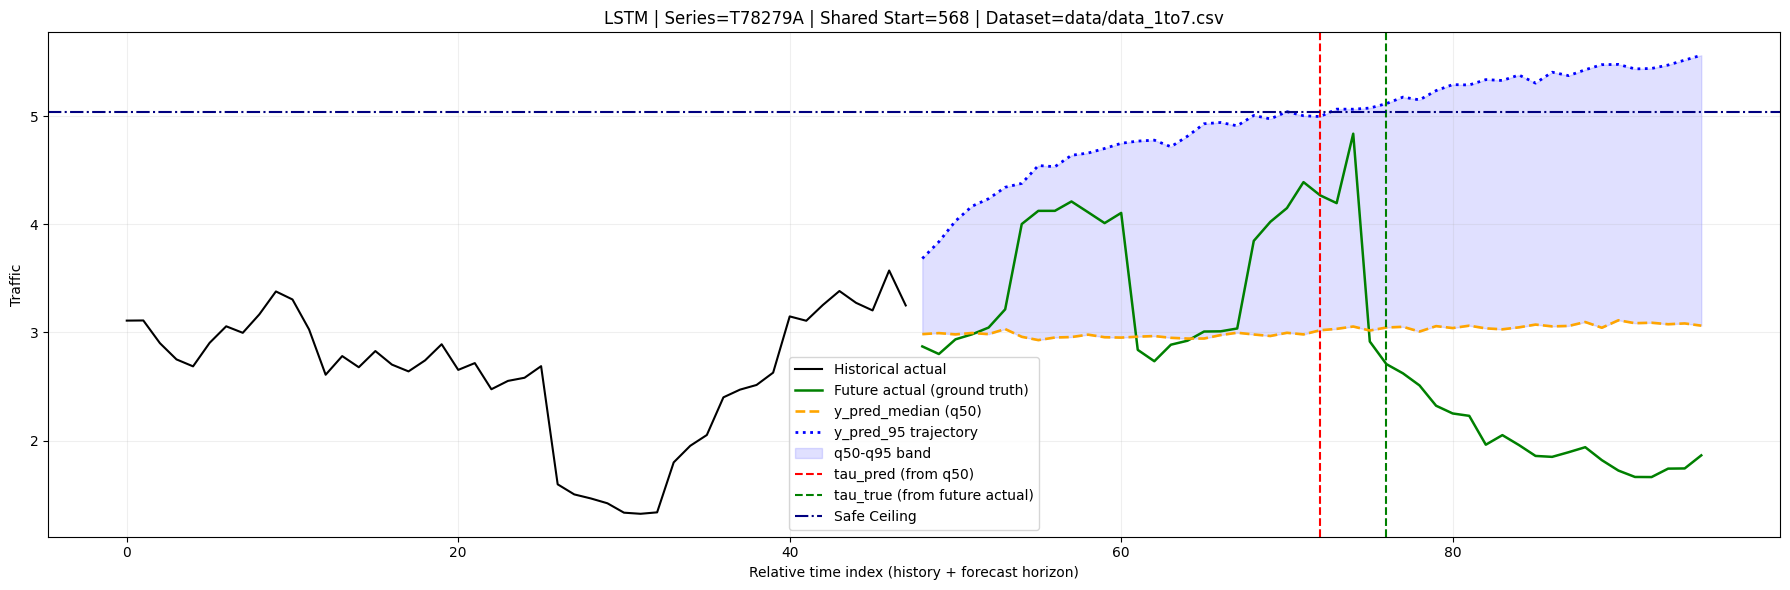

Saved plot: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/plots/plot_prob_T78279A_lstm_start568.png


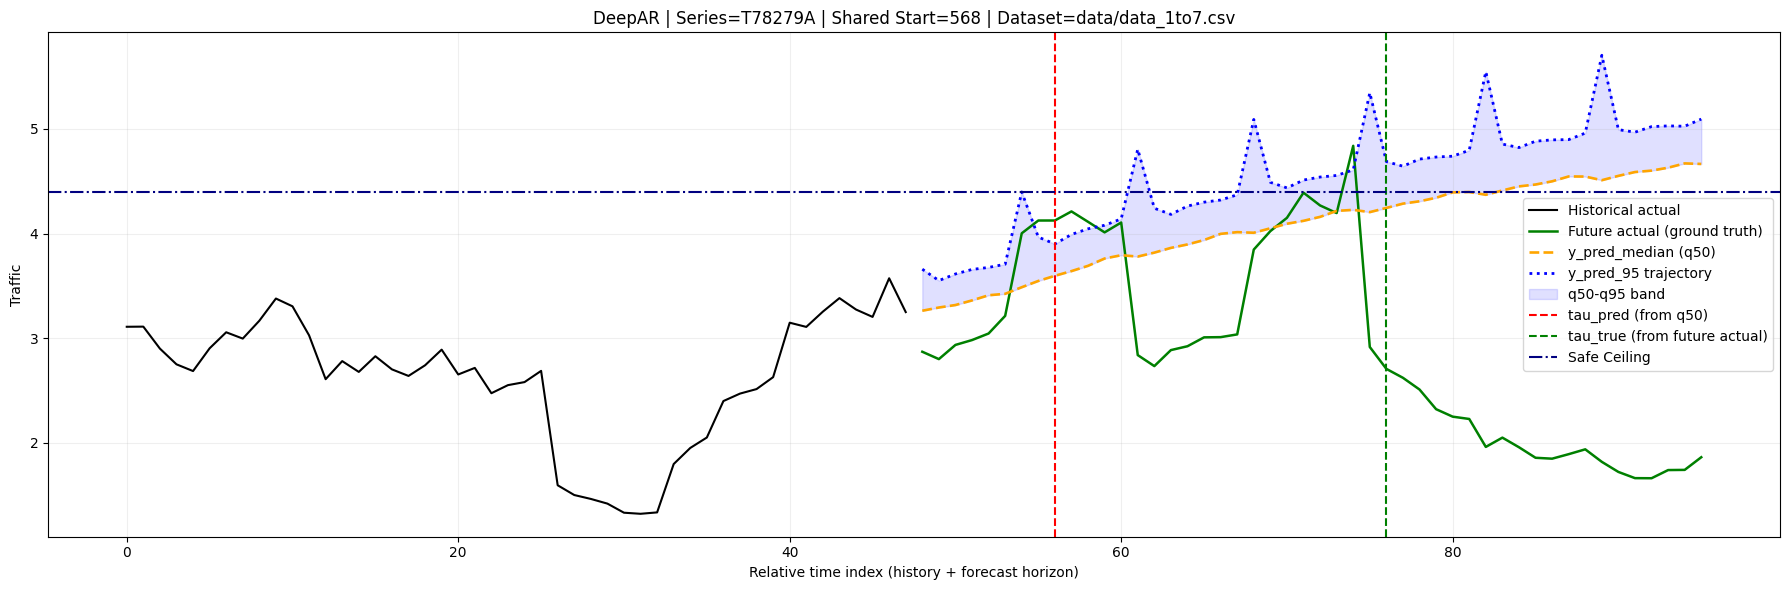

Saved plot: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/plots/plot_prob_T78279A_deepar_start568.png


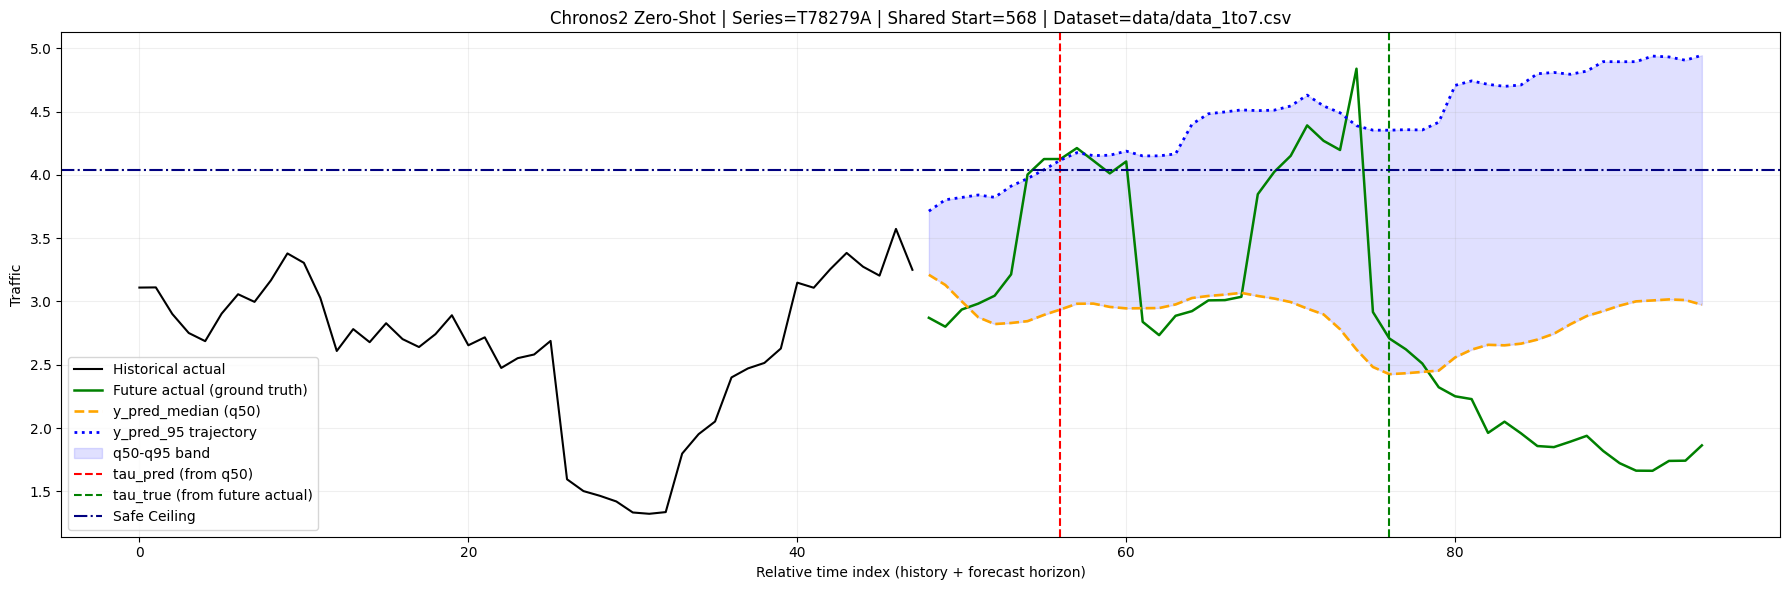

Saved plot: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/plots/plot_prob_T78279A_chronos2_start568.png
Finished probabilistic plotting with shared starts across systems.


In [4]:
from src.change_detection import RupturesPeltDetector
from src.pipeline import HybridForecastingChangePointPipeline, build_forecaster

MODEL_KEYS = ['lstm', 'deepar', 'chronos2']
MODEL_LABELS = {
    'lstm': 'LSTM',
    'deepar': 'DeepAR',
    'chronos2': 'Chronos2 Zero-Shot',
}
DATASET_PATH = ROOT / 'data' / 'data_1to7.csv'
EVAL_DIR = ROOT / 'results' / 'evaluation'
PLOTS_DIR = ROOT / 'results' / 'plots'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
RANDOM_SEED = 42
N_SERIES_TO_PLOT = 10

full_df = pd.read_csv(DATASET_PATH)
rng = np.random.default_rng(RANDOM_SEED)

checkpoint_map = {
    'lstm': ROOT / 'results' / 'models' / 'lstm_quantile_data_1to7_best.pt',
    'deepar': ROOT / 'results' / 'models' / 'deepar_quantile_data_1to7_best.pt',
}

detector = RupturesPeltDetector(model='normal', penalty=10.0, min_size=8, jump=1)

quantiles_tuple = tuple(float(x) for x in FORECASTER_QUANTILES.split(','))

forecasters = {
    'lstm': build_forecaster(
        'lstm',
        checkpoint_path=checkpoint_map['lstm'],
        context_length=CONTEXT_LENGTH,
        forecast_length=HORIZON,
        quantiles=quantiles_tuple,
        residual_sigma=None,
    ),
    'deepar': build_forecaster(
        'deepar',
        checkpoint_path=checkpoint_map['deepar'],
        context_length=CONTEXT_LENGTH,
        forecast_length=HORIZON,
        quantiles=quantiles_tuple,
    ),
    'chronos2': build_forecaster(
        'chronos2',
        context_length=CONTEXT_LENGTH,
        forecast_length=HORIZON,
    ),
}

pipelines = {
    key: HybridForecastingChangePointPipeline(
        forecaster=forecasters[key],
        change_detector=detector,
    )
    for key in MODEL_KEYS
}

windows_map = {
    key: pd.read_csv(EVAL_DIR / f'{key}_window_metrics.csv')
    for key in MODEL_KEYS
}

# Keep only series available for all systems.
series_sets = [set(df['series'].astype(str).unique().tolist()) for df in windows_map.values()]
common_series = sorted(set.intersection(*series_sets)) if series_sets else []
if not common_series:
    raise ValueError('No shared series found across LSTM/DeepAR/Chronos2 window metrics.')

num_to_plot = min(N_SERIES_TO_PLOT, len(common_series))
selected_series = sorted(rng.choice(common_series, size=num_to_plot, replace=False).tolist())
print('Selected shared series:', selected_series)

# For each selected series, force one shared start index across all systems.
shared_start_by_series = {}
for series_name in selected_series:
    common_starts = None
    for model_key in MODEL_KEYS:
        starts = set(
            windows_map[model_key]
            .loc[windows_map[model_key]['series'] == series_name, 'start_index']
            .astype(int)
            .tolist()
        )
        common_starts = starts if common_starts is None else (common_starts & starts)

    if not common_starts:
        print(f'No shared start index across systems for series={series_name}; skipping.')
        continue

    chosen_start = int(rng.choice(sorted(common_starts), size=1)[0])
    shared_start_by_series[series_name] = chosen_start

if not shared_start_by_series:
    raise ValueError('No comparable windows found (no shared start indices across systems).')

print('Shared start indices by series:', shared_start_by_series)

# Plot order: for each series -> LSTM, DeepAR, Chronos2
for series_name in selected_series:
    if series_name not in shared_start_by_series:
        continue

    start = shared_start_by_series[series_name]
    values = pd.to_numeric(full_df[series_name], errors='coerce').to_numpy(dtype=float)

    for model_key in MODEL_KEYS:
        history = values[start - CONTEXT_LENGTH:start]
        future_true = values[start:start + HORIZON]

        pred = pipelines[model_key].run(history=history, horizon=HORIZON)
        tau_true = detector.detect_first_change_point(future_true)

        hist_x = np.arange(CONTEXT_LENGTH)
        future_x = np.arange(CONTEXT_LENGTH, CONTEXT_LENGTH + HORIZON)

        plt.figure(figsize=(18, 6))
        plt.plot(hist_x, history, label='Historical actual', color='black', linewidth=1.5)
        plt.plot(future_x, future_true, label='Future actual (ground truth)', color='green', linewidth=1.8)
        plt.plot(future_x, pred.y_pred_median, label='y_pred_median (q50)', color='orange', linestyle='--', linewidth=1.9)
        plt.plot(future_x, pred.y_pred_95, label='y_pred_95 trajectory', color='blue', linestyle=':', linewidth=2.0)
        plt.fill_between(future_x, pred.y_pred_median, pred.y_pred_95, color='blue', alpha=0.12, label='q50-q95 band')

        if pred.tau_pred is not None:
            plt.axvline(CONTEXT_LENGTH + pred.tau_pred, color='red', linestyle='--', label='tau_pred (from q50)')
        if tau_true is not None:
            plt.axvline(CONTEXT_LENGTH + tau_true, color='green', linestyle='--', label='tau_true (from future actual)')

        plt.axhline(pred.safe_ceiling, color='navy', linestyle='-.', linewidth=1.5, label='Safe Ceiling')
        plt.title(
            f"{MODEL_LABELS[model_key]} | Series={series_name} | Shared Start={start} | Dataset=data/data_1to7.csv"
        )
        plt.xlabel('Relative time index (history + forecast horizon)')
        plt.ylabel('Traffic')
        plt.legend(loc='best')
        plt.grid(alpha=0.2)
        plt.tight_layout()

        out_path = PLOTS_DIR / f"plot_prob_{series_name}_{model_key}_start{start}.png"
        plt.savefig(out_path, dpi=160, bbox_inches='tight')
        plt.show()
        print('Saved plot:', out_path)

print('Finished probabilistic plotting with shared starts across systems.')
